USD MS AAI - 590 Capstone Project

## Melody Match — Music Similarity using MERT
Melody Match is a deep-learning system for classical music similarity search. 
<br>Given an audio query, it retrieves the most similar pieces from a 590-song corpus using semantic embeddings — not rule-based matching.
<br>The system fine-tunes MERT (Music Encoder Representations from Transformers, m-a-p/MERT-v1-95M),
<br>a 95M-parameter audio foundation model pre-trained on large-scale music data. Fine-tuning uses LoRA adapters
<br>and a TripletMarginLoss objective. Embeddings are indexed with FAISS for fast nearest-neighbour retrieval.

Group 3: Manikandan Perumal, Israel Romero Olvera and Darin Verduzco

GitHub: https://github.com/mperumal-usd/capstone_team_3

Dataset sources: 

Train/Validation: https://www.kaggle.com/datasets/soumikrakshit/classical-music-midi 
###      Testing Dataset: *****??????????



# Installs and Imports
# ************ To be combined from all notebooks

# EDA and Data Cleaning

# COLAB_Piano_Roll_test.ipynb

In [2]:
!apt-get install -y fluidsynth && pip install pyfluidsynth pretty_midi soundfile

In [5]:
import pretty_midi
import os
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import fluidsynth
from IPython.display import Audio

In [6]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now that your Google Drive is mounted, you can define the path to your subfolder. I will assume `AAI590_FinalProject` is directly under `MyDrive` for this example. If it's located elsewhere (e.g., under `Colab Notebooks`), you'll need to adjust the `subfolder_path` accordingly.

Based on your file list, there is a directory named `/content/drive/MyDrive/Colab Notebooks/MSAAI521_FinalProject/`. If `AAI590_FinalProject` was a typo and you meant `MSAAI521_FinalProject`, please adjust the `subfolder_path` variable below.

In [7]:
# Define the path to the subfolder
project_directory = '/content/drive/MyDrive/AAI590_FinalProject'

# Check if the directory exists
if os.path.exists(project_directory):
    print(f"Accessing: {project_directory}")
    # Change the current working directory to the subfolder
    os.chdir(project_directory)
    print(f"Current working directory: {os.getcwd()}")
    print("Contents of the subfolder:")
    # List the contents of the subfolder
    for item in os.listdir(project_directory):
        print(item)
else:
    print(f"The directory '{project_directory}' does not exist. Please check the path and try again.")
    print("You might have intended to access '/content/drive/MyDrive/Colab Notebooks/MSAAI521_FinalProject/' based on available files.")

Accessing: /content/drive/MyDrive/AAI590_FinalProject
Current working directory: /content/drive/MyDrive/AAI590_FinalProject
Contents of the subfolder:
590-Classical-music-midi
TestingSamples
ChunkSamples
.ipynb_checkpoints


In [8]:
from pathlib import Path

# Setting file system variables
midi_directory = f"{project_directory}/590-Classical-music-midi"
testing_directory = f"{project_directory}/TestingSamples"
chunks_directory = f"{project_directory}/ChunkSamples"


print("Project directory:", project_directory)
print("MIDI directory:", midi_directory)
print("Exists:", Path(midi_directory).exists())
print("Chunks directory:", chunks_directory)

Project directory: /content/drive/MyDrive/AAI590_FinalProject
MIDI directory: /content/drive/MyDrive/AAI590_FinalProject/590-Classical-music-midi
Exists: True
Chunks directory: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples


In [9]:
def load_midi_file(file_path: str, fs: int = 100) -> tuple[pretty_midi.PrettyMIDI | None, float | None, pretty_midi.TimeSignature | None, int]:
    """
    Loads a MIDI file from the given file path and returns its PrettyMIDI object,
    initial tempo, time signature, and the frames per second (fs) used for piano roll calculation.

    Args:
        file_path (str): The path to the MIDI file.
        fs (int): Frames per second to use for piano roll calculation (default: 100).

    Returns:
        tuple[pretty_midi.PrettyMIDI | None, float | None, pretty_midi.TimeSignature | None, int]:
            A tuple containing:
            - pretty_midi.PrettyMIDI object if successful, None otherwise.
            - Initial tempo of the MIDI file (float) if successful, None otherwise.
            - Initial time signature of the MIDI file (pretty_midi.TimeSignature) if successful, None otherwise.
            - Frames per second (fs) used for piano roll.
    """
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return None, None, None, fs # Return None for midi_data, tempo, and time_signature, but fs value

    try:
        midi_data = pretty_midi.PrettyMIDI(file_path)
        print(f"Successfully loaded MIDI file: {file_path}")

        tempo_times, tempos = midi_data.get_tempo_changes()
        print(f"Tempo changes loaded correctly")

        if(tempos.size > 0):
            print(f"Initial tempo: {tempos[0]}")
            initial_tempo = tempos[0]
        else:
            print(f"No tempo changes found in the MIDI file")
            initial_tempo = 120.0 # Default to 120 BPM if no tempo changes explicitly set
        #initial_tempo = tempos[0] if tempos else 120.0 # Default to 120 BPM if no tempo changes explicitly set
        print(f"Initial tempo selected correctly")

        initial_time_signature = midi_data.time_signature_changes[0] if midi_data.time_signature_changes else None
        print(f"Initial time signature loaded correctly")

        return midi_data, initial_tempo, initial_time_signature, fs
    except Exception as e:
        print(f"Error loading MIDI file {file_path}: {e}")
        return None, None, None, fs # Return None for midi_data, tempo, and time_signature, but fs value

In [10]:
def split_midi_by_measure(pm_data: pretty_midi.PrettyMIDI) -> list[pretty_midi.PrettyMIDI]:
    """
    Splits a PrettyMIDI object into a list of PrettyMIDI objects, one for each measure.
    Notes are adjusted to have start/end times relative to the beginning of their measure.

    Args:
        pm_data (pretty_midi.PrettyMIDI): The PrettyMIDI object to split.

    Returns:
        list[pretty_midi.PrettyMIDI]: A list of PrettyMIDI objects, each representing a measure.
    """
    measures = []
    downbeats = pm_data.get_downbeats()

    if not downbeats:
        print("No downbeats found. Returning original MIDI as a single measure.")
        return [pm_data]

    # Add an implicit end boundary if the last downbeat is not the very end of the piece
    end_time = max([note.end for instrument in pm_data.instruments for note in instrument.notes]) if pm_data.instruments else 0
    measure_boundaries = list(downbeats)
    if measure_boundaries[-1] < end_time:
        measure_boundaries.append(end_time)

    for i in range(len(measure_boundaries) - 1):
        measure_start_time = measure_boundaries[i]
        measure_end_time = measure_boundaries[i+1]

        # Create a new PrettyMIDI object for this measure
        measure_pm = pretty_midi.PrettyMIDI(resolution=pm_data.resolution)

        # Copy time signature and tempo map for the current measure if they fall within its bounds
        # This simplified approach assumes the first relevant time signature/tempo is representative.
        # A more robust solution would track changes throughout the measure.
        for ts in pm_data.time_signature_changes:
            if measure_start_time <= ts.time < measure_end_time:
                measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(ts.numerator, ts.denominator, 0)) # Set time to 0 for relative measure start
                break # Assuming one time signature per measure for simplicity
        if not measure_pm.time_signature_changes and pm_data.time_signature_changes:
             # If no explicit TS found in bounds, use the last one before measure start
             relevant_ts = [ts for ts in pm_data.time_signature_changes if ts.time <= measure_start_time]
             if relevant_ts:
                 last_ts = relevant_ts[-1]
                 measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(last_ts.numerator, last_ts.denominator, 0))
             else:
                measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(4, 4, 0)) # Default if nothing found
        elif not measure_pm.time_signature_changes:
            measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(4, 4, 0)) # Default if no TS in original MIDI

        # Iterate through instruments and notes
        for original_instrument in pm_data.instruments:
            new_instrument = pretty_midi.Instrument(program=original_instrument.program,
                                                    is_drum=original_instrument.is_drum,
                                                    name=original_instrument.name)
            for note in original_instrument.notes:
                # Check if the note is within the current measure's boundaries
                # A note is considered in the measure if its start time is within the measure,
                # or if it starts before and extends into the measure.
                if (measure_start_time <= note.start < measure_end_time) or \
                   (note.start < measure_start_time and note.end > measure_start_time):

                    # Adjust note start and end times relative to the measure's start
                    relative_start = max(0.0, note.start - measure_start_time)
                    relative_end = note.end - measure_start_time

                    # Ensure the note doesn't extend beyond the measure's relative end
                    relative_end = min(relative_end, measure_end_time - measure_start_time)

                    # Only add note if it has a positive duration within the measure
                    if relative_end > relative_start:
                        new_note = pretty_midi.Note(
                            velocity=note.velocity,
                            pitch=note.pitch,
                            start=relative_start,
                            end=relative_end
                        )
                        new_instrument.notes.append(new_note)
            if new_instrument.notes:
                measure_pm.instruments.append(new_instrument)

        measures.append(measure_pm)

    return measures

In [24]:
# Convert MIDI to audio wave file (required for MERT)
def midi_file_to_audio(midi_path, sr=24000):
    midi = pretty_midi.PrettyMIDI(midi_path)
    audio = midi.fluidsynth(fs=sr)
    return audio, sr
def midi_data_to_audio(midi_data, sr=24000):
    audio = midi_data.fluidsynth(fs=sr)
    return audio, sr
def save_audio(audio, sr, output_path):
    # Save the audio content to a WAV file
    sf.write(output_path, audio, sr)
    print(f"Audio saved to: {output_path}")
def create_midi_sequence_from_notes(notes, offset=0):
    """
    Creates a PrettyMIDI object from a list of note tuples.
    Each note tuple is expected to be (pitch, start, end, duration).
    """
    midi_sequence = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)  # Selecting Piano
    for note_array in notes:
        pitch, start, end, duration = note_array
        # Explicitly cast pitch to int, as numpy array might have cast it to float
        new_note = pretty_midi.Note(
            velocity=127,
            pitch=int(pitch),  # Ensure pitch is an integer
            start=start - offset,
            end=end - offset
        )
        instrument.notes.append(new_note)
    midi_sequence.instruments.append(instrument)
    return midi_sequence
def midi_to_note_sequence(midi_path):
    midi = pretty_midi.PrettyMIDI(midi_path)
    notes = []
    for instrument in midi.instruments:
        for note in instrument.notes:
            notes.append([
                int(note.pitch),  # Pitch must be int
                note.start,       # Keep as float for precise timing
                note.end,         # Keep as float for precise timing
                note.end - note.start # Duration (float)
            ])
    notes = sorted(notes, key=lambda x: x[1])
    return np.array(notes)
def chunk_notes(notes, chunk_size=32):
    chunks = []
    # Breaking into chunks with 50% overlap, so i will increment by chunk_size/2 each iteration
    chunk_iteration = int(chunk_size/2)
    for i in range(0, len(notes), chunk_iteration):
        chunk = notes[i:i+chunk_size]
        if len(chunk) == chunk_size:
            chunks.append(chunk)
    return chunks
def embed_chunks(chunks):
    embeddings = []
    for chunk in chunks:
        # simple numeric representation for MERT placeholder
        vec = chunk.flatten()
        embeddings.append(vec)
    return embeddings
def get_first_note_start_in_chunk(chunk):
    # Get all note start times
    note_start_times = [note[1] for note in chunk]
    # Get the first note time
    first_note_time = min(note_start_times)
    return first_note_time
def chunks_to_audio(chunks, output_wav_path):
    i = 1
    for chunk in chunks:
        tmp_output_path = output_wav_path.replace('.wav', f'_chunk_{i}.wav')
        #print(f'Preparing file {tmp_output_path}...')
        first_note_time = get_first_note_start_in_chunk(chunk)
        #print(f'First note time in chunk: {first_note_time}')
        midi_sequence = create_midi_sequence_from_notes(chunk, first_note_time)
        #print(f'Midi sequence for file {tmp_output_path}:')
        #print(midi_sequence)
        audio, sr = midi_data_to_audio(midi_sequence)
        save_audio(audio, sr, tmp_output_path)
        i += 1
    return i - 1
def create_chunks_from_midi(midi_path, sr=24000, chunk_size=32, audio_path=''):
    if(audio_path == ''):
        audio_path = midi_path
    wav_path = audio_path.replace('.mid', '.wav')
    notes = midi_to_note_sequence(midi_path)
    #print('Notes:')
    #print(notes)
    chunks = chunk_notes(notes, chunk_size)
    #print('Chunks')
    #print(chunks)
    chunk_file_count = chunks_to_audio(chunks, wav_path)
    print(f'Created {chunk_file_count} chunks from {midi_path}')

In [12]:
def get_frame_first_note(midi_content, fs):
  #Get all note start times
  note_start_times = [note.start for instrument in midi_content.instruments for note in instrument.notes]
  #Get the first note time
  first_note_time = min(note_start_times)
  #Calculate the frame in which the note shows up
  first_frame = int(first_note_time * fs)
  #Return the first frame
  return first_frame
def midi_to_pianoroll(midi_path):
  # Load MIDI
  midi_data, initial_tempo, initial_time_signature, piano_roll_fs = load_midi_file(midi_path)
  if midi_data is None:
      return None, None
  # Get first frame with a note
  first_active_frame = get_frame_first_note(midi_data, piano_roll_fs)

  # Full piano roll, shape: (128, time)
  piano_roll = midi_data.get_piano_roll(fs=piano_roll_fs)
  piano_roll = piano_roll / 127.0  # Normalize velocity
  piano_roll = piano_roll[:, first_active_frame:]  # Trim leading silence
  piano_roll = piano_roll.T  # Now shape: (time, 128)

  # Clip to valid MIDI range
  piano_roll = piano_roll[:, :128]

  return piano_roll, piano_roll_fs
def plot_piano_roll(midi_path, title="Piano Roll", save_path=None):
  #First we obtain the piano roll based on the path
  piano_roll, fs = midi_to_pianoroll(midi_path)
  time_steps = piano_roll.shape[0] #Getting timesteps
  duration = time_steps / fs #Calculating duration
  time_axis = np.linspace(0, duration, time_steps) #Preparing time axis dimension
  print(f'Time Steps: {time_steps}, Frames per Second: {fs}, Duration: {duration:.2f}s')
  #Next, we plot the Piano Roll
  plt.figure(figsize=(12, 6))
  plt.imshow(piano_roll.T, aspect='auto', origin='lower',
              extent=[0, duration, 0, piano_roll.shape[1]], cmap='gray_r')
  plt.xlabel('Time (s)')
  plt.ylabel('MIDI Note')
  plt.title(title)
  plt.tight_layout()

  if save_path:
      plt.savefig(save_path)
  else:
      plt.show()


In [13]:
# Assuming a MIDI file exists in the testing_directory
example_midi_path = os.path.join(testing_directory, 'MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid')

# Call the function and capture the returned values
midi_data_obj, initial_tempo, initial_time_signature, piano_roll_fs = load_midi_file(example_midi_path, fs=100)

# Print the captured parameters
if midi_data_obj:
    print(f"\nMIDI Data Object: {midi_data_obj}")
    print(f"Initial Tempo: {initial_tempo} BPM")
    if initial_time_signature:
        print(f"Initial Time Signature: {initial_time_signature.numerator}/{initial_time_signature.denominator}")
    else:
        print("Initial Time Signature: Not found")
    print(f"Frames Per Second (fs) for Piano Roll: {piano_roll_fs}")
else:
    print("Failed to load MIDI file.")

Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/TestingSamples/MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid
Tempo changes loaded correctly
Initial tempo: 75.0
Initial tempo selected correctly
Initial time signature loaded correctly

MIDI Data Object: <pretty_midi.pretty_midi.PrettyMIDI object at 0x7c8914c9b530>
Initial Tempo: 75.0 BPM
Initial Time Signature: 3/8
Frames Per Second (fs) for Piano Roll: 100


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/590-Classical-music-midi/beeth/elise.mid
Tempo changes loaded correctly
Initial tempo: 69.17997516438892
Initial tempo selected correctly
Initial time signature loaded correctly
Time Steps: 16473, Frames per Second: 100, Duration: 164.73s


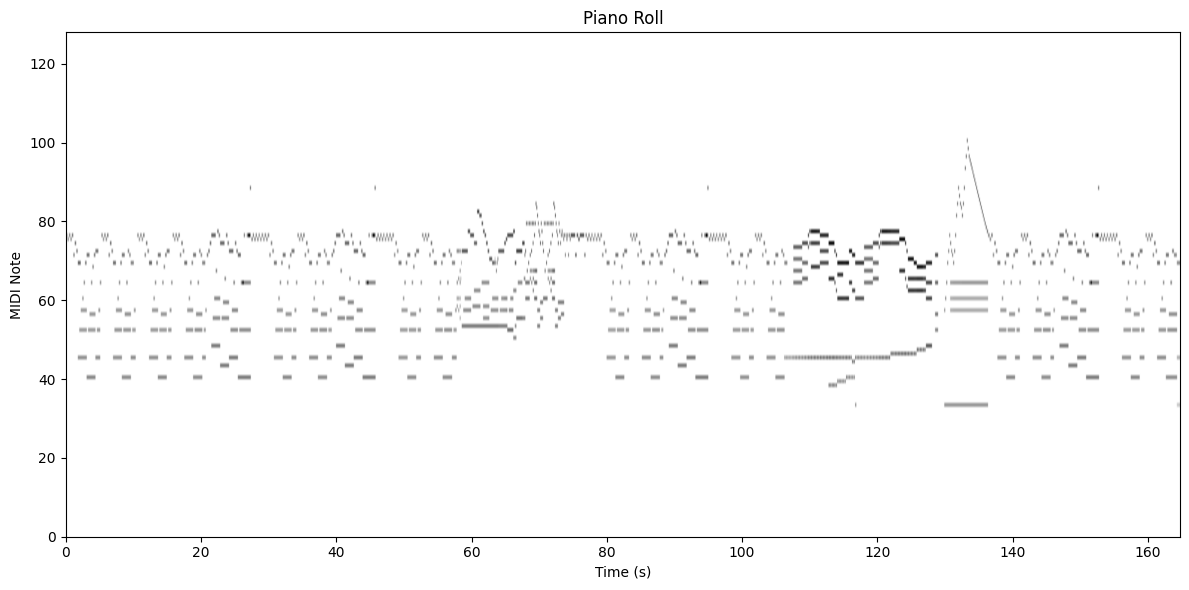

In [14]:
sample_path = f'{midi_directory}/beeth/elise.mid'
plot_piano_roll(sample_path)

Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/TestingSamples/MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid
Tempo changes loaded correctly
Initial tempo: 75.0
Initial tempo selected correctly
Initial time signature loaded correctly
Time Steps: 15691, Frames per Second: 100, Duration: 156.91s


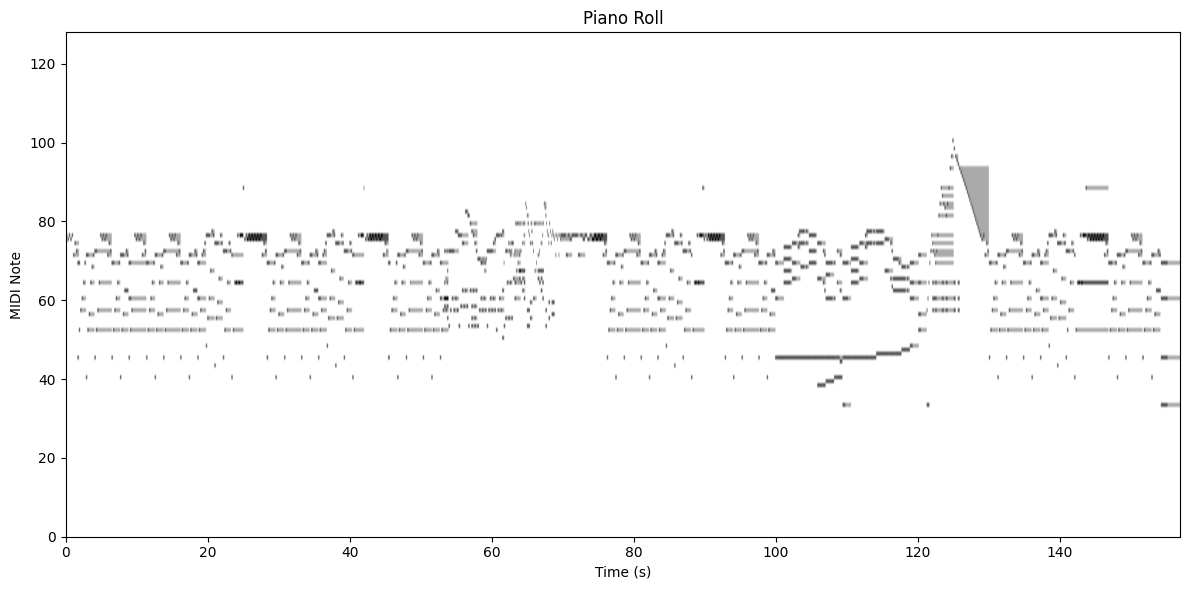

In [15]:
plot_piano_roll(example_midi_path)

In [28]:
import os
sample_file_name = os.path.basename(sample_path)

audio_path = f'{chunks_directory}/{Path(sample_file_name.replace('.mid','.wav'))}'

In [29]:
print(f'Sample_file_name: {sample_file_name}')
print(f'Audio Path: {audio_path}')


Sample_file_name: elise.mid
Audio Path: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise.wav


In [30]:
# Creating chunks and saving them into separate audio files
create_chunks_from_midi(sample_path, 24000, 32, audio_path)

Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_1.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_2.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_3.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_4.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_5.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_6.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_7.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_8.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_9.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_10.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_11.wav
Audio sa

In [1]:
import os
from pathlib import Path

# Ensure the base chunks directory exists
Path(chunks_directory).mkdir(parents=True, exist_ok=True)

print(f"Processing MIDI files from: {midi_directory}")
print(f"Saving audio chunks to: {chunks_directory}\n")

processed_midi_count = 0

for root, _, files in os.walk(midi_directory):
    for file in files:
        if file.endswith(('.mid', '.midi')):
            midi_file_path = os.path.join(root, file)

            # Construct the relative path from midi_directory
            relative_path = os.path.relpath(midi_file_path, midi_directory)

            # Create the corresponding output subdirectory within chunks_directory
            # The parent directory of the .wav file will be the new subfolder for the melody
            output_base_dir = os.path.join(chunks_directory, Path(relative_path).parent)
            Path(output_base_dir).mkdir(parents=True, exist_ok=True)

            # Construct the audio_path for the current MIDI file
            # This will be the base name for the WAV files (e.g., /path/to/chunks/melody_name/melody_name.wav)
            audio_path = os.path.join(output_base_dir, Path(file).stem)
            # although the chunk function will split it into melody_name_chunk_1.wav, melody_name_chunk_2.wav, etc...
            # The create_chunks_from_midi function will append _chunk_X.wav
            Path(audio_path).mkdir(parents=True, exist_ok=True)
            audio_file_name_base = Path(file).stem + '.wav'
            audio_path = os.path.join(audio_path, audio_file_name_base)

            # print(f"\nProcessing: {midi_file_path}")
            # print(f"Output audio base path: {audio_path}")

            try:
                create_chunks_from_midi(midi_file_path, sr=24000, chunk_size=32, audio_path=audio_path)
                processed_midi_count += 1
            except Exception as e:
                print(f"Error processing {midi_file_path}: {e}")

print(f"\nFinished processing {processed_midi_count} MIDI files.")

Streaming output truncated to the last 5000 lines.

Finished processing 292 MIDI files.


In [ ]:
from transformers import AutoModel, AutoProcessor

# Load MERT model
model_name = "m-a-p/MERT-v1-95M"

processor = AutoProcessor.from_pretrained(
    model_name,
    trust_remote_code=True
)

model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True
)

model.eval()

print("MERT model loaded successfully")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

MERT model loaded successfully


In [ ]:
import torch

# Get a list of all .wav files in the chunks_directory
chunk_wav_files = [os.path.join(chunks_directory, f) for f in os.listdir(chunks_directory) if f.endswith('.wav')]

# Sort the files for consistent processing order
chunk_wav_files.sort()

print(f"Found {len(chunk_wav_files)} WAV chunk files in {chunks_directory}")

all_chunk_embeddings = []

for i, wav_file in enumerate(chunk_wav_files):
    print(f"Processing chunk {i+1}/{len(chunk_wav_files)}: {wav_file}")
    try:
        # Load the audio file
        audio_input, sampling_rate = sf.read(wav_file)

        # Process the audio to get features MERT expects
        inputs = processor(raw_speech=audio_input, sampling_rate=sampling_rate, return_tensors="pt")

        # Generate embeddings
        with torch.no_grad():
            outputs = model(**inputs)

        # The MERT model outputs a 'last_hidden_state' which are the embeddings
        # We can take the mean across the time dimension to get a single embedding per chunk
        chunk_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        all_chunk_embeddings.append(chunk_embedding)
        print(f"  Generated embedding of shape: {chunk_embedding.shape}")

    except Exception as e:
        print(f"Error processing {wav_file}: {e}")

print("\nFinished generating embeddings for all chunks.")

# Convert list of embeddings to a numpy array for easier handling
if all_chunk_embeddings:
    all_chunk_embeddings_array = np.array(all_chunk_embeddings)
    print(f"Total embeddings array shape: {all_chunk_embeddings_array.shape}")
else:
    print("No embeddings were generated.")

Found 33 WAV chunk files in /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples
Processing chunk 1/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise.wav
  Generated embedding of shape: (768,)
Processing chunk 2/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_1.wav
  Generated embedding of shape: (768,)
Processing chunk 3/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_10.wav
  Generated embedding of shape: (768,)
Processing chunk 4/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_11.wav
  Generated embedding of shape: (768,)
Processing chunk 5/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_12.wav
  Generated embedding of shape: (768,)
Processing chunk 6/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_13.wav
  Generated embedding of shape: (768,)
Processing chunk 7/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_14.wav
  Gene

In [ ]:
all_chunk_embeddings_array

array([[-0.06526169, -0.08986434,  0.01106025, ..., -0.12569161,
         0.01292511,  0.15875973],
       [-0.05605015,  0.02903162,  0.1476077 , ...,  0.06878751,
        -0.12339675, -0.01053775],
       [-0.00215679,  0.06864046,  0.10211527, ...,  0.07713242,
        -0.158657  ,  0.07421888],
       ...,
       [-0.04903139,  0.0355635 ,  0.10422671, ...,  0.08874337,
        -0.03504748, -0.09810561],
       [-0.02771215, -0.02110263,  0.1903375 , ..., -0.0028037 ,
        -0.1456412 , -0.02211083],
       [-0.06512479,  0.02299381,  0.1268365 , ...,  0.04886309,
        -0.07233655, -0.11230969]], dtype=float32)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the cosine similarity matrix
cosine_sim_matrix = cosine_similarity(all_chunk_embeddings_array)

print("Cosine Similarity Matrix shape:", cosine_sim_matrix.shape)
print("\nFirst 5x5 block of the Cosine Similarity Matrix:")
display(cosine_sim_matrix[:5, :5])

Cosine Similarity Matrix shape: (33, 33)

First 5x5 block of the Cosine Similarity Matrix:


array([[0.9999999 , 0.3274981 , 0.33961865, 0.33189514, 0.31973848],
       [0.3274981 , 1.0000002 , 0.9625899 , 0.92657423, 0.9624461 ],
       [0.33961865, 0.9625899 , 0.99999994, 0.96453846, 0.98271596],
       [0.33189514, 0.92657423, 0.96453846, 1.        , 0.96836454],
       [0.31973848, 0.9624461 , 0.98271596, 0.96836454, 0.9999998 ]],
      dtype=float32)

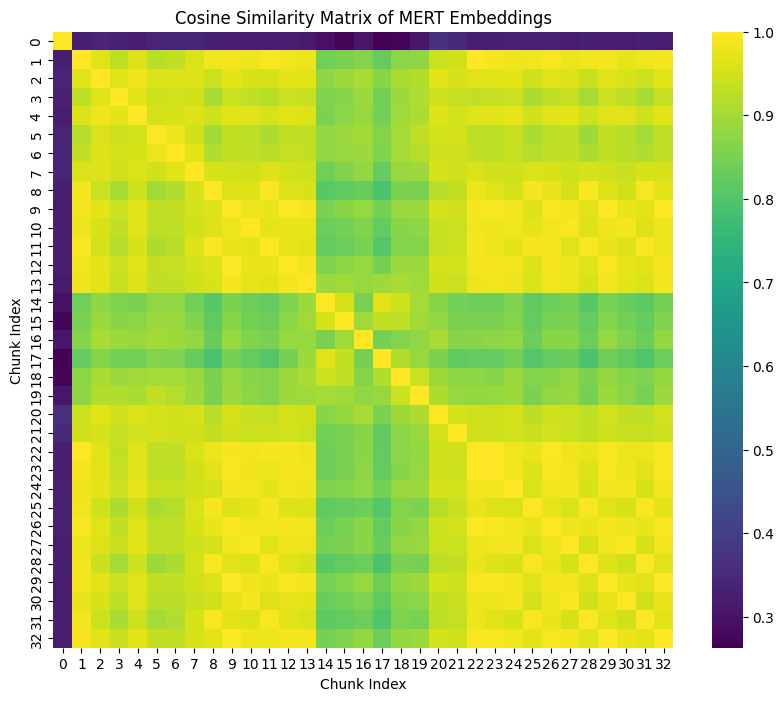

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_matrix, annot=False, cmap='viridis', fmt=".2f", cbar=True)
plt.title('Cosine Similarity Matrix of MERT Embeddings')
plt.xlabel('Chunk Index')
plt.ylabel('Chunk Index')
plt.show()

The output `cosine_sim_matrix` is a square matrix where `cosine_sim_matrix[i, j]` represents the cosine similarity between the embedding of chunk `i` and chunk `j`. Values close to 1 indicate high similarity, while values close to -1 indicate high dissimilarity. The diagonal elements will always be 1, as an embedding is perfectly similar to itself.

# Model Loading and Training

# COLAB_MERT_Finetune_v5.ipynb

# MERT Fine-Tuning with LoRA: Composer Similarity (v5)

Fine-tunes `m-a-p/MERT-v1-95M` using LoRA adapters on all attention projections.
No projection head — the 768-dim L2-normalized MERT output is used directly with TripletMarginLoss.

## Sections
- **Section 0** — Setup (install deps, mount Drive, config)
- **Section 1** — Triplet CSV generation (always regenerated)
- **Section 2** — Train/val split (skips if Drive files exist)
- **Section 3** — LoRA training (intra-epoch checkpointing every N steps)
- **Section 4** — Evaluation

**Resume after disconnect:** Run all cells top-to-bottom. Each section checks Drive for its checkpoint and skips if already done. Training resumes from the last saved step.

In [1]:
# ── Section 0: Setup ──────────────────────────────────────────────────────────
!pip install -q transformers peft accelerate librosa numpy pandas scikit-learn tqdm

from google.colab import drive
drive.mount('/content/drive')

import os, json, random, re
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import librosa
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
DRIVE_BASE   = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints5"
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
MODEL_NAME       = "m-a-p/MERT-v1-95M"
MODEL_CACHE_DIR  = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints5/model_cache"
SR           = 24000
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]
MARGIN       = 0.3
CNN_FILTERS  = 256           # filters per scale in CNN temporal encoder
CNN_KERNELS  = (3, 5, 7)     # multi-scale kernel sizes (frames)
EMBED_DIM    = 128           # final embedding dimension
BATCH_SIZE   = 8        # each triplet = 3 WAV forward passes through MERT
LR           = 5e-5
EPOCHS       = 10
SAVE_STEPS   = 1        # save full checkpoint to Drive after every optimizer step
GRAD_CLIP    = 1.0      # gradient clipping max norm (0 = disabled)
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Create Drive subdirectories
for sub in ["splits", "checkpoints/lora_best", "checkpoints/lora_last", "results", "model_cache"]:
    os.makedirs(os.path.join(DRIVE_BASE, sub), exist_ok=True)
print("Drive folders ready.")

Mounted at /content/drive
Device: cuda
Drive folders ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

## Section 1 — Triplet CSV Generation
Regenerates (anchor, positive, negative) DataFrame from ChunkSamples and saves to Drive.
Always re-runs (~30 seconds). Anchor = first chunk of each song; positives = remaining chunks;
negative = chunks from a randomly chosen different composer.

In [ ]:
# ── Section 1: Triplet CSV ────────────────────────────────────────────────────
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

def numeric_sort(f):
    match = re.search(r'_chunk_(\d+)\.wav$', f)
    return int(match.group(1)) if match else -1

data = []
used_negatives = set()

for composer in os.listdir(CHUNK_PATH):
    composer_path = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(composer_path):
        continue
    for song in os.listdir(composer_path):
        song_path = os.path.join(composer_path, song)
        if not os.path.isdir(song_path):
            continue
        chunks = sorted(
            [f for f in os.listdir(song_path) if f.endswith(".wav")],
            key=numeric_sort
        )
        if len(chunks) < 2:
            continue
        anchor    = chunks[0]
        positives = chunks[1:]
        other_composers = [
            c for c in os.listdir(CHUNK_PATH)
            if c != composer and os.path.isdir(os.path.join(CHUNK_PATH, c))
        ]
        if not other_composers:
            continue
        chosen_composer      = random.choice(other_composers)
        chosen_composer_path = os.path.join(CHUNK_PATH, chosen_composer)
        negative_pool = []
        for other_song in sorted(os.listdir(chosen_composer_path)):
            other_song_path = os.path.join(chosen_composer_path, other_song)
            if not os.path.isdir(other_song_path):
                continue
            for f in sorted(os.listdir(other_song_path), key=numeric_sort):
                if f.endswith(".wav") and f not in used_negatives:
                    negative_pool.append(f)
        min_len = min(len(positives), len(negative_pool))
        for i in range(min_len):
            data.append({
                "anchor":   anchor,
                "positive": positives[i],
                "negative": negative_pool[i],
                "composer": composer,
                "song":     song,
            })
            used_negatives.add(negative_pool[i])

df = pd.DataFrame(data)
df.to_csv(TRIPLET_CSV, index=False)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

In [3]:
df = pd.read_csv(TRIPLET_CSV)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

Triplet CSV saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/triplet_df.csv
Total triplets: 23183
                 anchor              positive             negative composer  \
0  bach_847_chunk_1.wav  bach_847_chunk_2.wav  islamei_chunk_1.wav     bach   
1  bach_847_chunk_1.wav  bach_847_chunk_3.wav  islamei_chunk_2.wav     bach   
2  bach_847_chunk_1.wav  bach_847_chunk_4.wav  islamei_chunk_3.wav     bach   
3  bach_847_chunk_1.wav  bach_847_chunk_5.wav  islamei_chunk_4.wav     bach   
4  bach_847_chunk_1.wav  bach_847_chunk_6.wav  islamei_chunk_5.wav     bach   

       song  
0  bach_847  
1  bach_847  
2  bach_847  
3  bach_847  
4  bach_847  


## Section 2 — Train/Val Split
80/20 stratified split on composer. Skips if Drive files already exist.

In [5]:
# ── Section 2: Train/val split ────────────────────────────────────────────────
TRAIN_IDX_PATH = os.path.join(DRIVE_BASE, "splits", "train_idx.npy")
VAL_IDX_PATH   = os.path.join(DRIVE_BASE, "splits",   "val_idx.npy")

if os.path.exists(TRAIN_IDX_PATH) and os.path.exists(VAL_IDX_PATH):
    train_idx = np.load(TRAIN_IDX_PATH)
    val_idx   = np.load(VAL_IDX_PATH)
    print(f"Loaded split from Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")
else:
    all_idx = np.arange(len(df))
    train_idx, val_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=SEED,
        stratify=df["composer"].values
    )
    np.save(TRAIN_IDX_PATH, train_idx)
    np.save(VAL_IDX_PATH,   val_idx)
    print(f"Split saved to Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
print(f"train_df: {len(train_df)} rows  val_df: {len(val_df)} rows")

Loaded split from Drive. Train: 18546  Val: 4637
train_df: 18546 rows  val_df: 4637 rows


## Section 3 — LoRA Training

### Architecture
```
MERT-v1-95M
  + LoRA adapters on q_proj, k_proj, v_proj, o_proj (all transformer layers)
  → mean-pool last_hidden_state → 768-dim
  → L2-normalize → 768-dim unit-sphere embedding
Loss: TripletMarginLoss(margin=0.3)
```

### Resume behaviour
Training state is saved every `SAVE_STEPS` optimizer steps to Drive (`training_state.json`).
On resume, the LoRA adapter and optimizer are reloaded and the loop skips already-completed batches.

In [7]:
# ── Section 3A: Dataset + Model setup ────────────────────────────────────────

# Build filename → full path lookup
file_lookup = {}
for composer in os.listdir(CHUNK_PATH):
    cp = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(cp):
        continue
    for song in os.listdir(cp):
        sp = os.path.join(cp, song)
        if not os.path.isdir(sp):
            continue
        for f in os.listdir(sp):
            if f.endswith(".wav"):
                file_lookup[f] = os.path.join(sp, f)
print(f"File lookup built: {len(file_lookup)} files")


class TripletWAVDataset(Dataset):
    """Loads WAV triplets on-the-fly from filenames."""
    def __init__(self, dataframe, file_lookup, processor, sr=24000):
        self.df          = dataframe.reset_index(drop=True)
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.df)

    def _load(self, fname):
        path  = self.file_lookup.get(fname)
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        # squeeze batch dim added by processor
        return {k: v.squeeze(0) for k, v in inputs.items()}

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return (
            self._load(row["anchor"]),
            self._load(row["positive"]),
            self._load(row["negative"]),
        )


def collate_triplets(batch):
    """Stack variable-length inputs by padding to the longest in the batch."""
    anchors, positives, negatives = zip(*batch)

    def stack(items):
        # items is a list of dicts; pad input_values to same length
        max_len = max(x["input_values"].shape[-1] for x in items)
        padded  = []
        for x in items:
            iv = x["input_values"]  # (seq_len,)
            pad_len = max_len - iv.shape[-1]
            padded.append(F.pad(iv, (0, pad_len)))
        return {"input_values": torch.stack(padded)}

    return stack(anchors), stack(positives), stack(negatives)


# ── Load processor + base model (Drive cache → HuggingFace fallback) ────────
if os.path.isdir(MODEL_CACHE_DIR) and os.listdir(MODEL_CACHE_DIR):
    print(f"Loading MERT from Drive cache: {MODEL_CACHE_DIR}")
    processor  = AutoProcessor.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
    base_model = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
else:
    print("Drive cache not found. Downloading from HuggingFace...")
    processor  = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
    base_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
    processor.save_pretrained(MODEL_CACHE_DIR)
    base_model.save_pretrained(MODEL_CACHE_DIR)
    print(f"Model cached to Drive: {MODEL_CACHE_DIR}")


# ── CNN Temporal Projection Head ────────────────────────────────────────────
import torch.nn as nn
class CNNProjectionHead(nn.Module):
    """
    Replaces mean-pooling with learned multi-scale temporal aggregation.

    Input : last_hidden_state  (batch, seq_len, 768)
    Output: L2-normalised embedding  (batch, EMBED_DIM)

    Three parallel Conv1d streams with different kernel sizes capture
    local (3-frame), mid (5-frame) and broader (7-frame) temporal patterns.
    Their global-average-pooled outputs are concatenated, then projected
    to EMBED_DIM via a two-layer MLP with LayerNorm + GELU.
    """
    def __init__(self, input_dim=768, num_filters=256,
                 kernel_sizes=(3, 5, 7), embed_dim=128, dropout=0.1):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(input_dim, num_filters, k, padding=k // 2),
                nn.BatchNorm1d(num_filters),
                nn.GELU(),
            )
            for k in kernel_sizes
        ])
        fused = num_filters * len(kernel_sizes)
        self.proj = nn.Sequential(
            nn.Linear(fused, fused // 2),
            nn.LayerNorm(fused // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fused // 2, embed_dim),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        # hidden_states: (batch, seq_len, 768)
        x = hidden_states.transpose(1, 2)           # → (batch, 768, seq_len)
        pooled = [conv(x).mean(dim=2) for conv in self.convs]
        x = torch.cat(pooled, dim=1)                # (batch, num_filters * n_kernels)
        return F.normalize(self.proj(x), p=2, dim=1)  # (batch, embed_dim)


# Apply LoRA
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS,
    lora_dropout=LORA_DROPOUT,
    bias="none",
)
model = get_peft_model(base_model, lora_config)
model.to(DEVICE)
model.print_trainable_parameters()

# Instantiate CNN projection head
cnn_head = CNNProjectionHead(
    input_dim    = 768,
    num_filters  = CNN_FILTERS,
    kernel_sizes = CNN_KERNELS,
    embed_dim    = EMBED_DIM,
    dropout      = 0.1,
).to(DEVICE)
cnn_params = sum(p.numel() for p in cnn_head.parameters())
print(f"CNN projection head: {cnn_params:,} params  (filters={CNN_FILTERS}, kernels={CNN_KERNELS}, embed={EMBED_DIM})")

# DataLoaders
train_dataset = TripletWAVDataset(train_df, file_lookup, processor, SR)
val_dataset   = TripletWAVDataset(val_df,   file_lookup, processor, SR)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)

criterion = torch.nn.TripletMarginLoss(margin=MARGIN, p=2)
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(cnn_head.parameters()), lr=LR
)
total_steps = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")
print(f"Total training steps: {total_steps}")

# ── Mixed-precision (AMP) setup ──────────────────────────────────────────────
use_amp = DEVICE.type == "cuda"
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)
print(f"Mixed precision (AMP): {use_amp}")


File lookup built: 43663 files
Loading MERT from Drive cache: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/model_cache


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

trainable params: 442,368 || all params: 94,814,080 || trainable%: 0.4666
CNN projection head: 3,296,768 params  (filters=256, kernels=(3, 5, 7), embed=128)
Train batches: 2319  Val batches: 580
Total training steps: 23190
Mixed precision (AMP): True


/tmp/ipykernel_6588/18749039.py:167: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)


In [8]:
# ── Section 3B: Training loop ─────────────────────────────────────────────────
LORA_BEST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_best")
LORA_LAST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_last")
CNN_BEST_PATH  = os.path.join(DRIVE_BASE, "checkpoints", "cnn_head_best.pt")
CNN_LAST_PATH  = os.path.join(DRIVE_BASE, "checkpoints", "cnn_head_last.pt")
OPT_STATE_PATH = os.path.join(DRIVE_BASE, "checkpoints", "optimizer_state.pt")
TRAIN_STATE    = os.path.join(DRIVE_BASE, "checkpoints", "training_state.json")
LOG_PATH       = os.path.join(DRIVE_BASE, "training_log.csv")


def get_embedding(model, batch_inputs):
    """Forward through LoRA-MERT → CNN projection head → L2-normed EMBED_DIM embedding."""
    inputs = {k: v.to(DEVICE) for k, v in batch_inputs.items()}
    outputs = model(**inputs)
    hidden = outputs.last_hidden_state      # (batch, seq_len, 768)
    return cnn_head(hidden)                 # (batch, EMBED_DIM) L2-normed


In [9]:


# ── Resume ────────────────────────────────────────────────────────────────────
start_epoch   = 0
resume_step   = 0       # steps already completed inside start_epoch
global_step   = 0
best_val_loss = float("inf")
training_log  = []

if os.path.exists(TRAIN_STATE):
    with open(TRAIN_STATE) as f:
        state = json.load(f)
    start_epoch   = state["epoch"]
    resume_step   = state["step"]       # batches done in start_epoch
    global_step   = state["global_step"]
    best_val_loss = state["best_val_loss"]
    # Load a fresh base model so PeftModel.from_pretrained has no stale
    # peft_config attached — avoids the "Already found peft_config" warning
    # and guarantees the new optimizer points at the correct parameters.
    opt_ckpt = torch.load(OPT_STATE_PATH, map_location=DEVICE)
    fresh_base = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
    model = PeftModel.from_pretrained(fresh_base, LORA_LAST_DIR)
    model.to(DEVICE)
    if os.path.exists(CNN_LAST_PATH):
        cnn_head.load_state_dict(torch.load(CNN_LAST_PATH, map_location=DEVICE))
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(cnn_head.parameters()), lr=LR
    )
    optimizer.load_state_dict(opt_ckpt["optimizer"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    scheduler.load_state_dict(opt_ckpt["scheduler"])
    if "scaler" in opt_ckpt:
        scaler.load_state_dict(opt_ckpt["scaler"])
    print(f"Resumed: epoch={start_epoch} step={resume_step} global_step={global_step}")
else:
    print("No checkpoint found. Training from scratch.")

if os.path.exists(LOG_PATH):
    training_log = pd.read_csv(LOG_PATH).to_dict(orient="records")


def save_checkpoint(is_best=False, end_of_epoch=False):
    """Save LoRA adapter + optimizer/scheduler/scaler state to Drive.
    end_of_epoch=True advances epoch/step so resume skips no batches.
    """
    model.save_pretrained(LORA_LAST_DIR)
    torch.save(cnn_head.state_dict(), CNN_LAST_PATH)
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler":    scaler.state_dict(),
    }, OPT_STATE_PATH)
    with open(TRAIN_STATE, "w") as f:
        json.dump({
            "epoch":         epoch + 1 if end_of_epoch else epoch,
            "step":          0         if end_of_epoch else batch_idx + 1,
            "global_step":   global_step,
            "best_val_loss": best_val_loss,
        }, f)
    if is_best:
        model.save_pretrained(LORA_BEST_DIR)
        torch.save(cnn_head.state_dict(), CNN_BEST_PATH)


# ── Training ──────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    model.train()
    cnn_head.train()
    train_loss_total = 0.0
    train_batches    = 0

    for batch_idx, (a_in, p_in, n_in) in enumerate(
        tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    ):
        # Skip already-completed batches on resume
        if epoch == start_epoch and batch_idx < resume_step:
            scheduler.step()
            global_step += 1
            continue

        with torch.cuda.amp.autocast(enabled=use_amp):
            a_emb = get_embedding(model, a_in)
            p_emb = get_embedding(model, p_in)
            n_emb = get_embedding(model, n_in)
            loss  = criterion(a_emb, p_emb, n_emb)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        if GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(cnn_head.parameters()), GRAD_CLIP
            )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss_total += loss.item()
        train_batches    += 1
        global_step      += 1

        # Intra-epoch checkpoint
        if global_step % SAVE_STEPS == 0:
            save_checkpoint(is_best=False)

    avg_train_loss = train_loss_total / max(train_batches, 1)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    cnn_head.eval()
    val_loss_total = 0.0
    val_pos_sim    = 0.0
    val_neg_sim    = 0.0

    with torch.no_grad():
        for a_in, p_in, n_in in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            with torch.cuda.amp.autocast(enabled=use_amp):
                a_emb = get_embedding(model, a_in)
                p_emb = get_embedding(model, p_in)
                n_emb = get_embedding(model, n_in)
                loss  = criterion(a_emb, p_emb, n_emb)
            val_loss_total += loss.item()
            val_pos_sim += F.cosine_similarity(a_emb, p_emb).mean().item()
            val_neg_sim += F.cosine_similarity(a_emb, n_emb).mean().item()

    avg_val_loss = val_loss_total / len(val_loader)
    avg_pos_sim  = val_pos_sim   / len(val_loader)
    avg_neg_sim  = val_neg_sim   / len(val_loader)

    # ── Log ───────────────────────────────────────────────────────────────────
    is_best = avg_val_loss < best_val_loss
    if is_best:
        best_val_loss = avg_val_loss

    row = {
        "epoch":       epoch + 1,
        "global_step": global_step,
        "train_loss":  round(avg_train_loss, 6),
        "val_loss":    round(avg_val_loss,   6),
        "val_pos_sim": round(avg_pos_sim,    4),
        "val_neg_sim": round(avg_neg_sim,    4),
        "val_gap":     round(avg_pos_sim - avg_neg_sim, 4),
        "lr":          optimizer.param_groups[0]["lr"],
        "best":        is_best,
    }
    training_log.append(row)
    pd.DataFrame(training_log).to_csv(LOG_PATH, index=False)

    # Save end-of-epoch checkpoint (and best if improved)
    save_checkpoint(is_best=is_best, end_of_epoch=True)
    resume_step = 0   # next epoch starts from batch 0

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} "
        f"pos_sim={avg_pos_sim:.4f} neg_sim={avg_neg_sim:.4f} "
        f"gap={avg_pos_sim - avg_neg_sim:.4f}"
        + ("  ✓ best" if is_best else "")
    )

print(f"\nTraining complete. Best val_loss={best_val_loss:.4f}")
print(f"Best LoRA adapter → {LORA_BEST_DIR}")

No checkpoint found. Training from scratch.


Epoch 1/10 [train]:   0%|          | 0/2319 [00:00<?, ?it/s]/tmp/ipykernel_6588/1951960872.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10 [val]:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_6588/1951960872.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10 [val]: 100%|██████████| 580/580 [20:01<00:00,  2.07s/it]


Epoch 01 | train_loss=0.0993 val_loss=0.0950 pos_sim=0.5630 neg_sim=0.0784 gap=0.4846  ✓ best


Epoch 2/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.20it/s]


Epoch 02 | train_loss=0.0560 val_loss=0.0628 pos_sim=0.5149 neg_sim=-0.0997 gap=0.6145  ✓ best


...

Epoch 08 | train_loss=0.0125 val_loss=0.0404 pos_sim=0.5475 neg_sim=-0.0514 gap=0.5989


Epoch 9/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.21it/s]


Epoch 09 | train_loss=0.0110 val_loss=0.0302 pos_sim=0.5196 neg_sim=-0.1301 gap=0.6497  ✓ best


Epoch 10/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.03it/s]

Epoch 10 | train_loss=0.0102 val_loss=0.0320 pos_sim=0.5208 neg_sim=-0.1277 gap=0.6486

Training complete. Best val_loss=0.0302
Best LoRA adapter → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/lora_best


## Section 4 — Evaluation
Loads the best LoRA adapter and computes cosine similarity distributions on the val set.
Saves results and a 2-panel histogram to Drive.

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Best LoRA adapter loaded from /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/lora_best
Best CNN head loaded  from /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/cnn_head_best.pt


Evaluating:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_6588/896868102.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating: 100%|██████████| 580/580 [00:37<00:00, 15.58it/s]


finetune_pos_mean  0.5196
finetune_neg_mean -0.1300
finetune_gap       0.6496
finetune_pos_std   0.2693
finetune_neg_std   0.2963


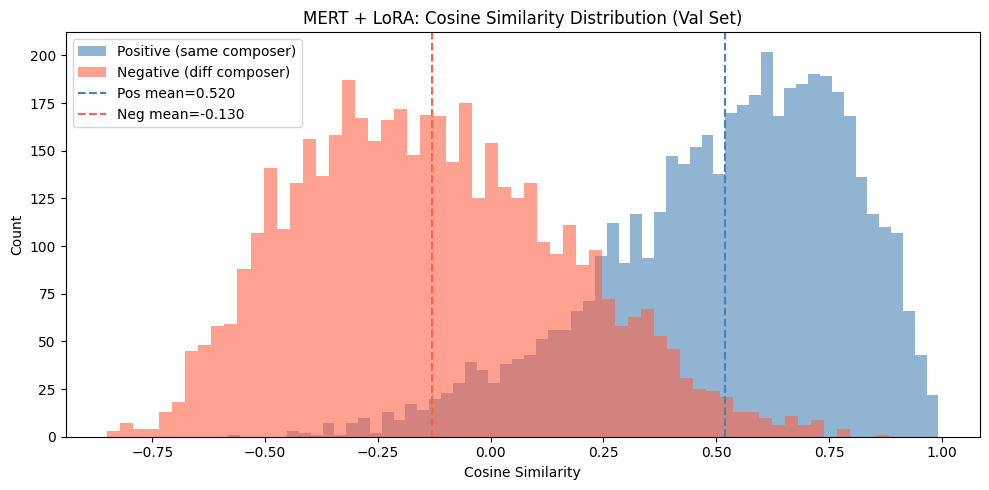

Plot saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/score_plot.png
Eval results saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/eval_results.csv


In [10]:
# ── Section 4: Evaluation ─────────────────────────────────────────────────────
EVAL_CSV  = os.path.join(DRIVE_BASE, "results", "eval_results.csv")
PLOT_PATH = os.path.join(DRIVE_BASE, "results", "score_plot.png")

# Load best LoRA adapter + CNN projection head
eval_base  = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
eval_model = PeftModel.from_pretrained(eval_base, LORA_BEST_DIR)
eval_model.to(DEVICE)
eval_model.eval()
cnn_head.load_state_dict(torch.load(CNN_BEST_PATH, map_location=DEVICE))
cnn_head.eval()
print(f"Best LoRA adapter loaded from {LORA_BEST_DIR}")
print(f"Best CNN head loaded  from {CNN_BEST_PATH}")

# ── Compute fine-tuned cosine similarities on val set ─────────────────────────
ft_pos_sims, ft_neg_sims = [], []

with torch.no_grad():
    for a_in, p_in, n_in in tqdm(val_loader, desc="Evaluating"):
        with torch.cuda.amp.autocast(enabled=use_amp):
            a_emb = get_embedding(eval_model, a_in)
            p_emb = get_embedding(eval_model, p_in)
            n_emb = get_embedding(eval_model, n_in)
        ft_pos_sims.append(F.cosine_similarity(a_emb, p_emb).cpu().numpy())
        ft_neg_sims.append(F.cosine_similarity(a_emb, n_emb).cpu().numpy())

ft_pos_sim = np.concatenate(ft_pos_sims)
ft_neg_sim = np.concatenate(ft_neg_sims)

# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "finetune_pos_mean": round(float(ft_pos_sim.mean()), 4),
    "finetune_neg_mean": round(float(ft_neg_sim.mean()), 4),
    "finetune_gap":      round(float(ft_pos_sim.mean() - ft_neg_sim.mean()), 4),
    "finetune_pos_std":  round(float(ft_pos_sim.std()),  4),
    "finetune_neg_std":  round(float(ft_neg_sim.std()),  4),
}
results_df = pd.DataFrame([results])
results_df.to_csv(EVAL_CSV, index=False)
print(results_df.T.to_string(header=False))

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ft_pos_sim, bins=60, alpha=0.6, label="Positive (same composer)", color="steelblue")
ax.hist(ft_neg_sim, bins=60, alpha=0.6, label="Negative (diff composer)", color="tomato")
ax.axvline(ft_pos_sim.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Pos mean={ft_pos_sim.mean():.3f}")
ax.axvline(ft_neg_sim.mean(), color="tomato",    linestyle="--", linewidth=1.5,
           label=f"Neg mean={ft_neg_sim.mean():.3f}")
ax.set_title("MERT + LoRA: Cosine Similarity Distribution (Val Set)")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"Plot saved → {PLOT_PATH}")
print(f"Eval results saved → {EVAL_CSV}")

## Section 5 — Extract All Embeddings
Extracts embeddings for all chunks in the dataset using the best fine-tuned model and saves them to a DataFrame.

In [12]:
# ── Section 5: Extract All Embeddings ─────────────────────────────────────────

all_files = list(file_lookup.keys())

class AllChunksDataset(Dataset):
    """Dataset for extracting embeddings from all chunks."""
    def __init__(self, file_list, file_lookup, processor, sr=24000):
        self.file_list   = file_list
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        path  = self.file_lookup[fname]
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        return fname, {k: v.squeeze(0) for k, v in inputs.items()}

def collate_all_chunks(batch):
    fnames, items = zip(*batch)
    max_len = max(x["input_values"].shape[-1] for x in items)
    padded  = []
    for x in items:
        iv = x["input_values"]
        pad_len = max_len - iv.shape[-1]
        padded.append(F.pad(iv, (0, pad_len)))
    return fnames, {"input_values": torch.stack(padded)}

all_dataset = AllChunksDataset(all_files, file_lookup, processor, SR)
all_loader  = DataLoader(
    all_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)

results_data = []
eval_model.eval()
cnn_head.eval()

with torch.no_grad():
    for fnames, batch_inputs in tqdm(all_loader, desc="Extracting all embeddings"):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_embedding(eval_model, batch_inputs)
        embs_np = embs.cpu().numpy()

        for fname, emb in zip(fnames, embs_np):
            chunk_match = re.search(r'_chunk_(\d+)\.wav$', fname)
            chunk_num = int(chunk_match.group(1)) if chunk_match else -1
            results_data.append({
                "filename": fname,
                "chunk": chunk_num,
                "embeddings": emb
            })

all_embeddings_df = pd.DataFrame(results_data)

# Save to pickle to preserve numpy arrays naturally
EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "all_embeddings.pkl")
all_embeddings_df.to_pickle(EMBEDDINGS_PATH)

print(f"\nSaved {len(all_embeddings_df)} embeddings to {EMBEDDINGS_PATH}")
display(all_embeddings_df.head())

Extracting all embeddings: 100%|██████████| 5458/5458 [35:09<00:00,  2.59it/s]



Saved 43663 embeddings to /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/all_embeddings.pkl


,filename,chunk,embeddings
0,bach_847_chunk_1.wav,1,"[0.05016434, 0.069372244, -0.009370848, 0.0846..."
1,bach_847_chunk_2.wav,2,"[0.049578503, 0.091372475, 0.0034356404, 0.139..."
2,bach_847_chunk_3.wav,3,"[0.06047059, 0.08120336, 0.0074810754, 0.16503..."
3,bach_847_chunk_4.wav,4,"[0.06594905, 0.08882934, 0.0069581256, 0.17710..."
4,bach_847_chunk_5.wav,5,"[0.05413191, 0.11070533, 0.018642722, 0.173556..."


In [17]:
import json
import os

notebook_path = '/content/drive/MyDrive/AAI-590 Capstone/capstone_team_3/notebooks/COLAB_MERT_Finetune_v3.ipynb'

if os.path.exists(notebook_path):
    with open(notebook_path, 'r') as f:
        nb = json.load(f)

    print("--- Extracting FAISS Sections (Cells 22 to 30) ---")

    # Print cells 22 to 30 to avoid truncation limit
    for i, cell in enumerate(nb.get('cells', [])[22:30], start=22):
        source = "".join(cell.get('source', []))
        if not source.strip():
            continue

        print(f"\n{'='*60}\nCell {i} Type: {cell.get('cell_type')}\n{'='*60}")
        print(source)
else:
    print(f"File not found: {notebook_path}")

--- Extracting FAISS Sections (Cells 22 to 30) ---

Cell 22 Type: markdown
## Section 5 — FAISS Indexing and Validation
Install FAISS and split the embeddings dataset 80/20. The 80% split acts as our database, and the 20% split acts as our validation queries. We will measure Recall@K to see how often a chunk from the same song is retrieved in the top K results.

Cell 23 Type: code
!pip install -q faiss-cpu

Cell 24 Type: code
import faiss
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the embeddings
OUT_PKL = os.path.join(DRIVE_BASE, "results", "chunk_embeddings.pkl")
print(f"Loading embeddings from: {OUT_PKL}")
df_emb = pd.read_pickle(OUT_PKL)

# Extract just the 768-dim embedding columns
emb_cols = [f"emb_{i}" for i in range(768)]

# 2. Split 80% Index (Database) / 20% Validation (Queries)
train_df, val_df = train_test_split(df_emb, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_

## Section 6 — FAISS Indexing and Evaluation
Builds a FAISS index from 80% of the chunk embeddings and queries the remaining 20% to measure **Recall@K** at the song level (i.e., whether a chunk from the same song appears in the top-K retrieved chunks).

In [18]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 104.1 MB/s eta 0:00:00


In [19]:
import faiss
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the 128-dim embeddings extracted in Section 5
EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "all_embeddings.pkl")
print(f"Loading embeddings from: {EMBEDDINGS_PATH}")
df_emb = pd.read_pickle(EMBEDDINGS_PATH)

# 2. Split 80% Index (Database) / 20% Validation (Queries)
train_df, val_df = train_test_split(df_emb, test_size=0.2, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Total chunks: {len(df_emb)}")
print(f"Database (Index) size: {len(train_df)}")
print(f"Validation (Query) size: {len(val_df)}")

# 3. Build FAISS Index
# Our embeddings from the CNN head are 128-dim and L2-normalized.
d = EMBED_DIM
index = faiss.IndexFlatL2(d)

# Convert arrays to float32 contiguous arrays for FAISS
train_embs = np.vstack(train_df['embeddings'].values).astype('float32')
val_embs = np.vstack(val_df['embeddings'].values).astype('float32')

index.add(train_embs)
print(f"\nFAISS index built. Total vectors indexed: {index.ntotal}")

Loading embeddings from: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/all_embeddings.pkl
Total chunks: 43663
Database (Index) size: 34930
Validation (Query) size: 8733

FAISS index built. Total vectors indexed: 34930


In [20]:
# 4. Calculate Recall@K
print("\n--- Calculating Recall@K on Validation Set ---")
max_k = 10
D_val, I_val = index.search(val_embs, max_k)

recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}

for i in range(len(val_df)):
    query_filename = val_df.iloc[i]['filename']
    # Extract song name by stripping the chunk suffix (e.g. 'bach_847_chunk_1.wav' -> 'bach_847')
    query_song = query_filename.rsplit('_chunk_', 1)[0]

    # Get the filenames of the top K results
    match_filenames = train_df.iloc[I_val[i]]['filename'].values
    match_songs = [f.rsplit('_chunk_', 1)[0] for f in match_filenames]

    for k in recall_at_k.keys():
        # A match is successful if the SAME song is found in the top K
        if query_song in match_songs[:k]:
            recall_at_k[k] += 1

# 5. Display Results
results_data = []
for k, count in recall_at_k.items():
    recall = count / len(val_df)
    results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

recall_df = pd.DataFrame(results_data)
display(recall_df)


--- Calculating Recall@K on Validation Set ---
Recall@01: 0.6363
Recall@03: 0.7363
Recall@05: 0.7791
Recall@10: 0.8333


,K,Recall
0,1,0.636322
1,3,0.736288
2,5,0.779114
3,10,0.833276


/tmp/ipykernel_6588/718218038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')


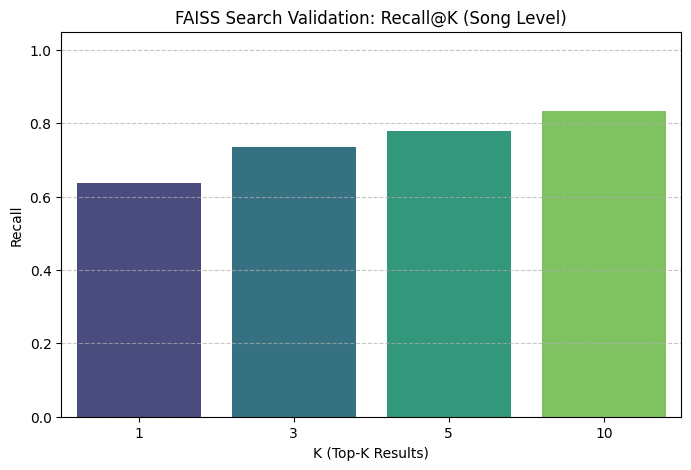

In [21]:
# 6. Plot the Recall@K results
plt.figure(figsize=(8, 5))
sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')

plt.title('FAISS Search Validation: Recall@K (Song Level)')
plt.xlabel('K (Top-K Results)')
plt.ylabel('Recall')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Section 7 — Baseline Model Comparison
Extracts embeddings using the pre-trained base MERT model (mean-pooling over the last hidden state) for the exact same index and query sets to compare Recall@K against the fine-tuned model.

In [22]:
# 1. Load the Base Model
print("Loading base MERT model for comparison...")
base_model = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
base_model.to(DEVICE)
base_model.eval()

def get_baseline_embedding(model, batch_inputs):
    """Standard mean-pooling over the last hidden state for the base model."""
    inputs = {k: v.to(DEVICE) for k, v in batch_inputs.items()}
    outputs = model(**inputs)
    hidden = outputs.last_hidden_state      # (batch, seq_len, 768)
    mean_pooled = hidden.mean(dim=1)        # (batch, 768)
    return F.normalize(mean_pooled, p=2, dim=1)

# 2. Create DataLoaders for the exact same split
train_files = train_df['filename'].tolist()
val_files = val_df['filename'].tolist()

base_train_dataset = AllChunksDataset(train_files, file_lookup, processor, SR)
base_val_dataset   = AllChunksDataset(val_files, file_lookup, processor, SR)

base_train_loader = DataLoader(
    base_train_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)
base_val_loader = DataLoader(
    base_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)

Loading base MERT model for comparison...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [23]:
# 3. Extract Baseline Embeddings
base_train_embs_list = []
base_val_embs_list = []

print("Extracting baseline database (index) embeddings...")
with torch.no_grad():
    for fnames, batch_inputs in tqdm(base_train_loader):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_baseline_embedding(base_model, batch_inputs)
        base_train_embs_list.append(embs.cpu().numpy())

print("\nExtracting baseline validation (query) embeddings...")
with torch.no_grad():
    for fnames, batch_inputs in tqdm(base_val_loader):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_baseline_embedding(base_model, batch_inputs)
        base_val_embs_list.append(embs.cpu().numpy())

base_train_embs = np.vstack(base_train_embs_list).astype('float32')
base_val_embs = np.vstack(base_val_embs_list).astype('float32')

Extracting baseline database (index) embeddings...


100%|██████████| 4367/4367 [01:15<00:00, 58.16it/s]



Extracting baseline validation (query) embeddings...


100%|██████████| 1092/1092 [00:19<00:00, 56.57it/s]


In [24]:
# 4. Build Baseline FAISS Index & Calculate Recall@K
d_base = 768  # Base MERT hidden size
index_base = faiss.IndexFlatL2(d_base)
index_base.add(base_train_embs)
print(f"\nBaseline FAISS index built. Total vectors: {index_base.ntotal}")

print("\n--- Calculating Baseline Recall@K ---")
D_base_val, I_base_val = index_base.search(base_val_embs, max_k)

base_recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}

for i in range(len(val_df)):
    query_song = val_df.iloc[i]['filename'].rsplit('_chunk_', 1)[0]

    match_filenames = train_df.iloc[I_base_val[i]]['filename'].values
    match_songs = [f.rsplit('_chunk_', 1)[0] for f in match_filenames]

    for k in base_recall_at_k.keys():
        if query_song in match_songs[:k]:
            base_recall_at_k[k] += 1

base_results_data = []
for k, count in base_recall_at_k.items():
    recall = count / len(val_df)
    base_results_data.append({"K": k, "Recall": recall})
    print(f"Baseline Recall@{k:02d}: {recall:.4f}")

base_recall_df = pd.DataFrame(base_results_data)


Baseline FAISS index built. Total vectors: 34930

--- Calculating Baseline Recall@K ---
Baseline Recall@01: 0.4545
Baseline Recall@03: 0.5557
Baseline Recall@05: 0.6069
Baseline Recall@10: 0.6785


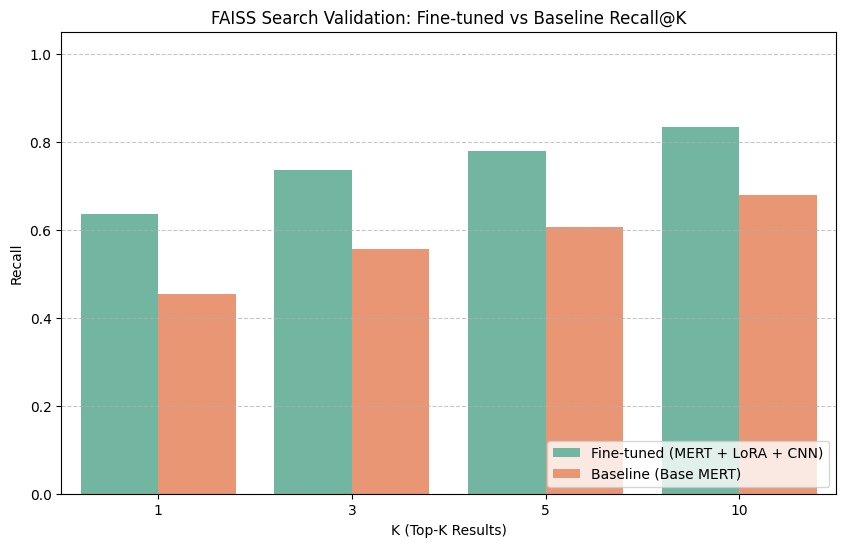

In [25]:
# 5. Plot Comparison
recall_df['Model'] = 'Fine-tuned (MERT + LoRA + CNN)'
base_recall_df['Model'] = 'Baseline (Base MERT)'

combined_recall_df = pd.concat([recall_df, base_recall_df], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='K', y='Recall', hue='Model', data=combined_recall_df, palette='Set2')

plt.title('FAISS Search Validation: Fine-tuned vs Baseline Recall@K')
plt.xlabel('K (Top-K Results)')
plt.ylabel('Recall')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

In [26]:
# 6. Save Comparison Results to CSV
COMPARISON_CSV = os.path.join(DRIVE_BASE, "results", "recall_comparison.csv")
combined_recall_df.to_csv(COMPARISON_CSV, index=False)
print(f"Comparison results saved to: {COMPARISON_CSV}")
display(combined_recall_df)

Comparison results saved to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/recall_comparison.csv


,K,Recall,Model
0,1,0.636322,Fine-tuned (MERT + LoRA + CNN)
1,3,0.736288,Fine-tuned (MERT + LoRA + CNN)
2,5,0.779114,Fine-tuned (MERT + LoRA + CNN)
3,10,0.833276,Fine-tuned (MERT + LoRA + CNN)
4,1,0.454483,Baseline (Base MERT)
5,3,0.555708,Baseline (Base MERT)
6,5,0.606893,Baseline (Base MERT)
7,10,0.678461,Baseline (Base MERT)


## Section 8 — Extract Embeddings for Testing Chunks
Extracts 128-dim embeddings for the testing chunks using the fine-tuned model (MERT + LoRA + CNN Head) and saves them to a DataFrame.

In [28]:
# 1. Setup Test Directory and File Lookup
TEST_CHUNK_DIR = "/content/drive/MyDrive/AAI-590 Capstone/capstone_team_3/MidiDatasets/TestingSamples/TestChunks"

test_file_lookup = {}
if os.path.exists(TEST_CHUNK_DIR):
    for root, dirs, files in os.walk(TEST_CHUNK_DIR):
        for f in files:
            if f.endswith(".wav"):
                test_file_lookup[f] = os.path.join(root, f)
else:
    print(f"Directory not found: {TEST_CHUNK_DIR}")

test_files = list(test_file_lookup.keys())
print(f"Found {len(test_files)} test chunks.")

if len(test_files) > 0:
    # 2. Create Dataset and DataLoader
    test_dataset = AllChunksDataset(test_files, test_file_lookup, processor, SR)
    test_loader  = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
    )

    test_results_data = []
    eval_model.eval()
    cnn_head.eval()

    # 3. Extract Embeddings
    with torch.no_grad():
        for fnames, batch_inputs in tqdm(test_loader, desc="Extracting test embeddings"):
            with torch.amp.autocast('cuda', enabled=use_amp):
                embs = get_embedding(eval_model, batch_inputs)
            embs_np = embs.cpu().numpy()

            for fname, emb in zip(fnames, embs_np):
                chunk_match = re.search(r'_chunk_(\d+)\.wav$', fname)
                chunk_num = int(chunk_match.group(1)) if chunk_match else -1
                test_results_data.append({
                    "filename": fname,
                    "chunk": chunk_num,
                    "embeddings": emb
                })

    test_embeddings_df = pd.DataFrame(test_results_data)

    # 4. Save to Pickle
    TEST_EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "test_embeddings.pkl")
    test_embeddings_df.to_pickle(TEST_EMBEDDINGS_PATH)

    print(f"\nSaved {len(test_embeddings_df)} test embeddings to {TEST_EMBEDDINGS_PATH}")
    display(test_embeddings_df.head())


Found 4116 test chunks.


Extracting test embeddings: 100%|██████████| 515/515 [16:48<00:00,  1.96s/it]


Saved 4116 test embeddings to /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_embeddings.pkl


,filename,chunk,embeddings
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,1,"[0.08296363, 0.01914027, -0.032113865, 0.10129..."
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,2,"[-0.07060223, -0.090025745, -0.06342004, 0.004..."
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,3,"[0.040199764, 0.013747733, -0.07446841, -0.000..."
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,4,"[0.019444987, -0.042106975, -0.09272113, -0.02..."
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,5,"[0.10372586, 0.049052797, -0.026465032, 0.1032..."


## Section 9 — FAISS Search for Testing Chunks
Loads the test embeddings `.pkl` and queries the FAISS index to find the top 10 closest matches from the database for each testing chunk. The output is a formatted DataFrame containing the query file name, the top 1-10 matches, and their similarity scores.

In [29]:
# 1. Load Test Embeddings
TEST_EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "test_embeddings.pkl")
print(f"Loading test embeddings from: {TEST_EMBEDDINGS_PATH}")
test_df = pd.read_pickle(TEST_EMBEDDINGS_PATH)

# 2. Prepare for FAISS Query
# Convert embeddings to float32 contiguous arrays
test_embs = np.vstack(test_df['embeddings'].values).astype('float32')

# 3. Query the FAISS Index (Top 10)
k_matches = 10
print(f"\nQuerying FAISS index for the top {k_matches} matches...")
D_test, I_test = index.search(test_embs, k_matches)

# 4. Format Results into a DataFrame
search_results = []

for i in range(len(test_df)):
    query_fname = test_df.iloc[i]['filename']
    row_data = {'Query_File': query_fname}

    for rank in range(k_matches):
        match_idx = I_test[i][rank]
        match_fname = train_df.iloc[match_idx]['filename']
        l2_dist = D_test[i][rank]

        # Convert L2 distance to Cosine Similarity (valid for L2-normalized vectors)
        # Formula: Cosine_Similarity = 1 - (L2_Distance^2 / 2)
        # Note: FAISS IndexFlatL2 returns squared L2 distance directly.
        cos_sim = 1.0 - (l2_dist / 2.0)

        row_data[f'Rank_{rank+1}_Match'] = match_fname
        row_data[f'Rank_{rank+1}_Sim'] = round(float(cos_sim), 4)

    search_results.append(row_data)

test_search_results_df = pd.DataFrame(search_results)

# 5. Save and Display Results
TEST_SEARCH_CSV = os.path.join(DRIVE_BASE, "results", "test_search_results.csv")
test_search_results_df.to_csv(TEST_SEARCH_CSV, index=False)

print(f"\nSaved FAISS search results for testing chunks to: {TEST_SEARCH_CSV}")
display(test_search_results_df.head())

Loading test embeddings from: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_embeddings.pkl

Querying FAISS index for the top 10 matches...

Saved FAISS search results for testing chunks to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_search_results.csv


,Query_File,Rank_1_Match,Rank_1_Sim,Rank_2_Match,Rank_2_Sim,Rank_3_Match,Rank_3_Sim,Rank_4_Match,Rank_4_Sim,Rank_5_Match,...,Rank_6_Match,Rank_6_Sim,Rank_7_Match,Rank_7_Sim,Rank_8_Match,Rank_8_Sim,Rank_9_Match,Rank_9_Sim,Rank_10_Match,Rank_10_Sim
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,alb_se6_chunk_41.wav,0.9710,alb_se6_chunk_6.wav,0.9618,alb_se6_chunk_39.wav,0.9608,alb_se6_chunk_40.wav,0.9581,schub_d960_1_chunk_523.wav,...,ty_april_chunk_51.wav,0.9481,beethoven_opus90_1_chunk_85.wav,0.9451,ty_april_chunk_50.wav,0.9432,bach_846_chunk_60.wav,0.9429,ty_april_chunk_28.wav,0.9419
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,liz_rhap12_chunk_119.wav,0.8454,waldstein_1_chunk_221.wav,0.8066,liz_rhap12_chunk_115.wav,0.8057,liz_rhap12_chunk_118.wav,0.8048,liz_rhap12_chunk_117.wav,...,schubert_D850_1_chunk_301.wav,0.7968,liz_donjuan_chunk_450.wav,0.7881,waldstein_1_chunk_99.wav,0.7777,alb_se6_chunk_13.wav,0.7760,liz_rhap12_chunk_114.wav,0.7720
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,alb_se6_chunk_23.wav,0.9397,muss_8_chunk_138.wav,0.9375,brahms_opus1_4_chunk_298.wav,0.9273,schubert_D935_4_chunk_207.wav,0.9262,muss_8_chunk_25.wav,...,schubert_D850_4_chunk_101.wav,0.9223,chpn_op25_e3_chunk_17.wav,0.9194,alb_se6_chunk_15.wav,0.9188,schuim-1_chunk_220.wav,0.9181,beethoven_opus10_1_chunk_155.wav,0.9165
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,alb_se6_chunk_23.wav,0.9230,chpn-p12_chunk_12.wav,0.9137,grieg_march_chunk_17.wav,0.9121,grieg_march_chunk_18.wav,0.9041,alb_se6_chunk_22.wav,...,grieg_wedding_chunk_163.wav,0.9000,alb_se6_chunk_15.wav,0.8999,beethoven_opus10_1_chunk_155.wav,0.8990,schuim-1_chunk_220.wav,0.8969,grieg_wedding_chunk_35.wav,0.8942
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,alb_se6_chunk_41.wav,0.9526,haydn_9_2_chunk_70.wav,0.9474,ty_april_chunk_28.wav,0.9467,ty_april_chunk_46.wav,0.9440,ty_april_chunk_29.wav,...,ty_april_chunk_47.wav,0.9420,ty_april_chunk_27.wav,0.9418,ty_april_chunk_51.wav,0.9397,ty_april_chunk_48.wav,0.9385,alb_se6_chunk_6.wav,0.9379


## Section 10 — Test Set Recall Calculation
Calculates Recall@1, 3, 5, and 10 for the test chunks using the ground truth mapping from `TestingReferences.csv`.

In [34]:
import pandas as pd
import os

# 1. Load the ground truth references
REF_CSV = '/content/TestingReferences.csv'
print(f"Loading references from: {REF_CSV}")
ref_df = pd.read_csv(REF_CSV)
display(ref_df.head())

# Use 'FileName' as query and 'OriginalFileName' as ground truth.
col_query = 'FileName'
col_truth = 'OriginalFileName'
print(f"\nUsing '{col_query}' as query and '{col_truth}' as ground truth.\n")

# Clean extensions from truth mapping keys and values
truth_mapping = {}
for q, t in zip(ref_df[col_query], ref_df[col_truth]):
    if pd.isna(q) or pd.isna(t): continue
    clean_q = str(q).rsplit('.', 1)[0]
    clean_t = str(t).rsplit('.', 1)[0]
    truth_mapping[clean_q] = clean_t

# 2. Calculate Recall@K
recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}
total_evaluated = 0

# Assuming test_search_results_df is in memory from Section 9.
# If not, load it: test_search_results_df = pd.read_csv(TEST_SEARCH_CSV)
for _, row in test_search_results_df.iterrows():
    query_file = row['Query_File']

    # Strip '_chunk_...' to match the cleaned truth_mapping keys
    base_query = query_file.rsplit('_chunk_', 1)[0]

    if base_query not in truth_mapping:
        continue

    true_song = truth_mapping[base_query]
    total_evaluated += 1

    # Extract predicted song names from the top 10 matches
    predicted_songs = []
    for rank in range(1, 11):
        match_file = row[f'Rank_{rank}_Match']
        # Strip the chunk suffix to get the base song name
        pred_song = match_file.rsplit('_chunk_', 1)[0]
        predicted_songs.append(pred_song)

    # Check for hits at different K values
    for k in recall_at_k.keys():
        if true_song in predicted_songs[:k]:
            recall_at_k[k] += 1

# 3. Display the final results
print(f"Total valid queries evaluated: {total_evaluated}")
results_data = []
for k, hits in recall_at_k.items():
    recall = hits / total_evaluated if total_evaluated > 0 else 0
    results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

test_recall_df = pd.DataFrame(results_data)
display(test_recall_df)


Loading references from: /content/TestingReferences.csv


,FileName,FullTestPath,OriginalFileName
0,FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.wav,audio/Beethoven/FurElise_Intro-2ndVers_K-Amin_...,elise.mid
1,FurElise_Intro_K-Amaj_T-138_bothhands_swing.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-138_bo...,elise.mid
2,FurElise_Intro_K-Amaj_T-138_righthand_swing.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-138_ri...,elise.mid
3,FurElise_Intro_K-Amaj_T-70_righthand.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-70_rig...,elise.mid
4,FurElise_Intro_K-Cmin_T-65_righthand.wav,audio/Beethoven/FurElise_Intro_K-Cmin_T-65_rig...,elise.mid



Using 'FileName' as query and 'OriginalFileName' as ground truth.

Total valid queries evaluated: 4116
Recall@01: 0.0794
Recall@03: 0.1412
Recall@05: 0.1781
Recall@10: 0.2512


,K,Recall
0,1,0.079446
1,3,0.141156
2,5,0.178086
3,10,0.251215


## Section 11 — Save Detailed Match Results
Combines the FAISS search results with the extracted chunk numbers and original ground truth names, then saves to a CSV.

In [36]:
import pandas as pd
import os
import re

detailed_results = []

for _, row in test_search_results_df.iterrows():
    query_file = row['Query_File']

    # Extract base query and chunk number
    base_query = query_file.rsplit('_chunk_', 1)[0]
    chunk_match = re.search(r'_chunk_(\d+)\.wav$', query_file)
    chunk_num = int(chunk_match.group(1)) if chunk_match else -1

    # Get original ground truth name
    original_name = truth_mapping.get(base_query, "Unknown")

    # Build the row dictionary
    row_data = {
        'Test_File_Name': query_file,
        'Chunk_Number': chunk_num,
        'Original_Name': original_name
    }

    # Add top 1-10 matches from the FAISS results, stripping the chunk suffix
    for rank in range(1, 11):
        match_file = row[f'Rank_{rank}_Match']
        pred_song = match_file.rsplit('_chunk_', 1)[0] if isinstance(match_file, str) else match_file
        row_data[f'Top_{rank}_Match'] = pred_song
        row_data[f'Top_{rank}_Sim'] = row[f'Rank_{rank}_Sim']

    detailed_results.append(row_data)

detailed_df = pd.DataFrame(detailed_results)

# Save to Drive
DETAILED_CSV_PATH = os.path.join(DRIVE_BASE, "results", "test_detailed_matches.csv")
detailed_df.to_csv(DETAILED_CSV_PATH, index=False)

print(f"Saved {len(detailed_df)} detailed matches to: {DETAILED_CSV_PATH}")
display(detailed_df.head())


Saved 4116 detailed matches to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_detailed_matches.csv


,Test_File_Name,Chunk_Number,Original_Name,Top_1_Match,Top_1_Sim,Top_2_Match,Top_2_Sim,Top_3_Match,Top_3_Sim,Top_4_Match,...,Top_6_Match,Top_6_Sim,Top_7_Match,Top_7_Sim,Top_8_Match,Top_8_Sim,Top_9_Match,Top_9_Sim,Top_10_Match,Top_10_Sim
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,1,alb_se6,alb_se6,0.9710,alb_se6,0.9618,alb_se6,0.9608,alb_se6,...,ty_april,0.9481,beethoven_opus90_1,0.9451,ty_april,0.9432,bach_846,0.9429,ty_april,0.9419
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,2,alb_se6,liz_rhap12,0.8454,waldstein_1,0.8066,liz_rhap12,0.8057,liz_rhap12,...,schubert_D850_1,0.7968,liz_donjuan,0.7881,waldstein_1,0.7777,alb_se6,0.7760,liz_rhap12,0.7720
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,3,alb_se6,alb_se6,0.9397,muss_8,0.9375,brahms_opus1_4,0.9273,schubert_D935_4,...,schubert_D850_4,0.9223,chpn_op25_e3,0.9194,alb_se6,0.9188,schuim-1,0.9181,beethoven_opus10_1,0.9165
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,4,alb_se6,alb_se6,0.9230,chpn-p12,0.9137,grieg_march,0.9121,grieg_march,...,grieg_wedding,0.9000,alb_se6,0.8999,beethoven_opus10_1,0.8990,schuim-1,0.8969,grieg_wedding,0.8942
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,5,alb_se6,alb_se6,0.9526,haydn_9_2,0.9474,ty_april,0.9467,ty_april,...,ty_april,0.9420,ty_april,0.9418,ty_april,0.9397,ty_april,0.9385,alb_se6,0.9379


## Section 12 — Final Recall Calculation (Cleaned Names)
Calculates the final Recall metrics directly from the cleaned base names in the detailed matches dataframe.

In [37]:
# Calculate Recall@K from the cleaned detailed_df
recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}
total_evaluated = len(detailed_df)

for _, row in detailed_df.iterrows():
    true_song = row['Original_Name']

    # Skip if ground truth mapping was not found
    if true_song == "Unknown":
        total_evaluated -= 1
        continue

    # Extract top 10 predicted base song names
    predicted_songs = [row[f'Top_{rank}_Match'] for rank in range(1, 11)]

    # Check for hits at different K values
    for k in recall_at_k.keys():
        if true_song in predicted_songs[:k]:
            recall_at_k[k] += 1

print(f"Total valid queries evaluated: {total_evaluated}")
final_results_data = []
for k, hits in recall_at_k.items():
    recall = hits / total_evaluated if total_evaluated > 0 else 0
    final_results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

final_recall_df = pd.DataFrame(final_results_data)
display(final_recall_df)


Total valid queries evaluated: 4116
Recall@01: 0.0794
Recall@03: 0.1412
Recall@05: 0.1781
Recall@10: 0.2512


,K,Recall
0,1,0.079446
1,3,0.141156
2,5,0.178086
3,10,0.251215


# Model Evaluation

## Section 13 — Error Analysis (Missed at Rank 1)
Analyzing cases where the correct song was not the top prediction to understand common confusions and whether the correct song was still nearby in the Top 5.

Total queries missed at Rank 1: 3789 out of 4116
Caught in Ranks 2-5: 406 (10.72%)

--- Top 10 Most Common Confusions (True -> Predicted) ---
21 times: mz_331_1 -> liz_donjuan
21 times: mz_331_1 -> chpn_op33_2
20 times: alb_esp6 -> alb_se5
19 times: mz_311_1 -> schubert_D850_4
18 times: mz_331_1 -> schubert_D850_1
17 times: beethoven_hammerklavier_1 -> beethoven_hammerklavier_3
14 times: mz_331_1 -> mz_331_3
14 times: mz_333_1 -> schub_d960_4
13 times: mz_331_1 -> chpn_op7_2
12 times: mond_1 -> schuim-4


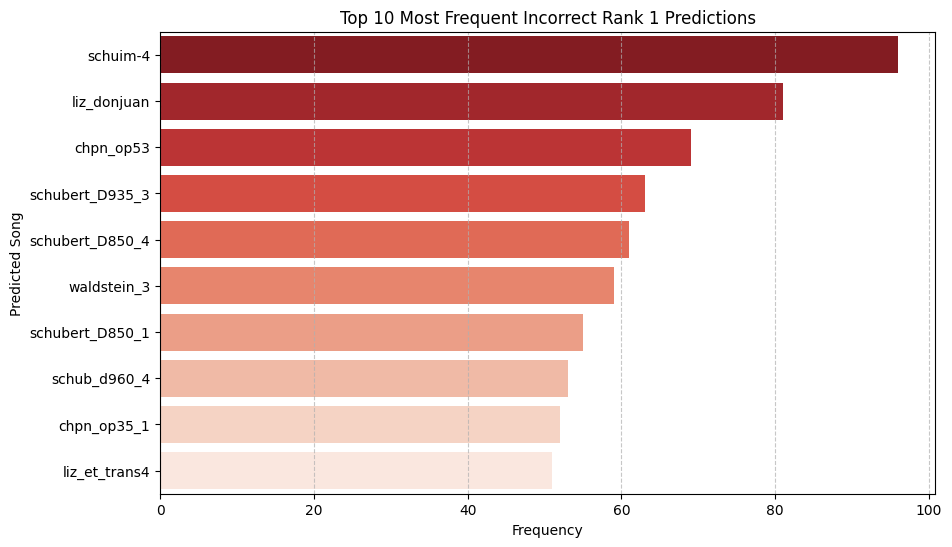

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Filter for valid queries where Rank 1 was incorrect
missed_rank1_df = detailed_df[(detailed_df['Original_Name'] != 'Unknown') &
                              (detailed_df['Original_Name'] != detailed_df['Top_1_Match'])]

print(f"Total queries missed at Rank 1: {len(missed_rank1_df)} out of {total_evaluated}")

# 1. Did it appear in Top 2-5?
caught_in_top5 = 0
for _, row in missed_rank1_df.iterrows():
    true_song = row['Original_Name']
    predicted_2_to_5 = [row[f'Top_{rank}_Match'] for rank in range(2, 6)]
    if true_song in predicted_2_to_5:
        caught_in_top5 += 1

print(f"Caught in Ranks 2-5: {caught_in_top5} ({caught_in_top5/len(missed_rank1_df):.2%})")

# 2. Most common confusions (True Song -> Incorrect Rank 1 Prediction)
confusions = missed_rank1_df.apply(lambda row: f"{row['Original_Name']} -> {row['Top_1_Match']}", axis=1)
top_confusions = Counter(confusions).most_common(10)

print("\n--- Top 10 Most Common Confusions (True -> Predicted) ---")
for conf, count in top_confusions:
    print(f"{count} times: {conf}")

# 3. What is the model predicting most often when it's wrong?
top_wrong_predictions = missed_rank1_df['Top_1_Match'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_wrong_predictions.values, y=top_wrong_predictions.index, hue=top_wrong_predictions.index, palette='Reds_r', legend=False)
plt.title('Top 10 Most Frequent Incorrect Rank 1 Predictions')
plt.xlabel('Frequency')
plt.ylabel('Predicted Song')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


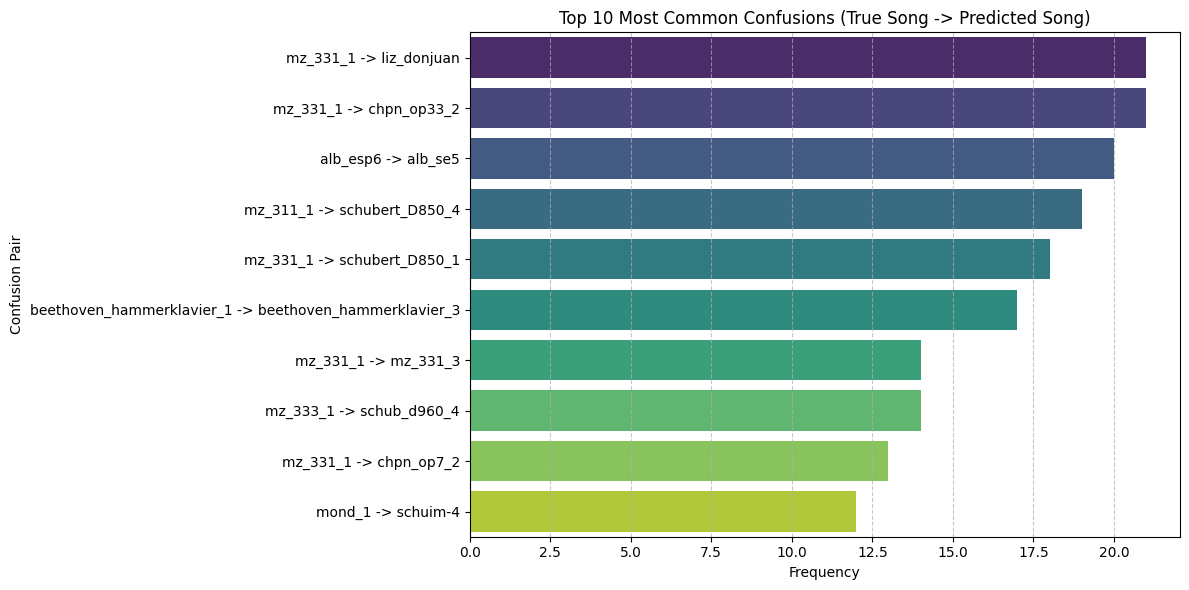

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract labels and counts from top_confusions
conf_labels = [conf for conf, count in top_confusions]
conf_counts = [count for conf, count in top_confusions]

plt.figure(figsize=(12, 6))
sns.barplot(x=conf_counts, y=conf_labels, hue=conf_labels, palette='viridis', legend=False)
plt.title('Top 10 Most Common Confusions (True Song -> Predicted Song)')
plt.xlabel('Frequency')
plt.ylabel('Confusion Pair')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# COLAB_MERT_FAISS_Recall_Eval.ipynb

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mperumal-usd/capstone_team_3/blob/main/notebooks/COLAB_CNN_MEL_Similarity.ipynb)

# CNN Mel-Spectrogram Similarity Search

Embeds audio chunks using **mel spectrograms → pretrained ResNet18 CNN** (no MERT).
Indexes all classic ChunkSamples, then queries with TestSamples chunks via FAISS.

## Sections
- **Section 0** — Setup (install deps, mount Drive, config)
- **Section 1** — Mel spectrogram + CNN embedding pipeline
- **Section 2** — Build classic chunk embeddings (index database)
- **Section 3** — FAISS index construction
- **Section 4** — Build test chunk embeddings
- **Section 5** — Similarity search & results
- **Section 6** — Recall@K evaluation (requires TestingReferences.csv)

In [1]:
# ── Section 0: Setup ──────────────────────────────────────────────────────────
!pip install -q librosa soundfile faiss-cpu tqdm numpy pandas scikit-learn matplotlib seaborn

from google.colab import drive
drive.mount('/content/drive')

import os, re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms as transforms
import librosa
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ────────────────────────────────────────────────────────────────────
DRIVE_BASE      = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints_cnn_mel"
CHUNK_PATH      = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
TEST_CHUNK_DIR  = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/TestingSamples/TestChunks"
REF_CSV_PATH    = "/content/TestingReferences.csv"   # upload to Colab if available

# Mel spectrogram parameters
SR          = 24000
N_MELS      = 128
N_FFT       = 1024
HOP_LENGTH  = 512
MEL_H       = 128   # height (mel bins) after resize
MEL_W       = 128   # width  (time frames) after resize

# CNN / embedding parameters
EMBED_DIM   = 512   # ResNet18 avg-pool output dimension
BATCH_SIZE  = 32
SEED        = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Create output directories
for sub in ["results"]:
    os.makedirs(os.path.join(DRIVE_BASE, sub), exist_ok=True)
print("Drive folders ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 86.5 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda
Drive folders ready.


## Section 1 — Mel Spectrogram + CNN Embedding Pipeline

### Architecture
```
WAV (24 kHz)
  → librosa.feature.melspectrogram  (128 mel bins)
  → power_to_db + normalize → [0, 1]
  → resize to 128×128
  → repeat channel ×3  (grayscale → RGB-like)
  → ResNet18 (pretrained, FC removed)
  → 512-dim global avg-pool feature
  → L2-normalize → 512-dim unit-sphere embedding
```

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


MelCNNEmbedder loaded. Total params: 11,176,512  Embed dim: 512
Sanity check on: /content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples/bach/bach_847/bach_847_chunk_1.wav


/tmp/ipykernel_3352/1890556920.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((mel_norm * 255).astype(np.uint8), mode='L')


  Mel tensor shape : (3, 128, 128)  range [0.000, 0.980]
  Embedding shape  : (1, 512)  L2-norm: 1.0000


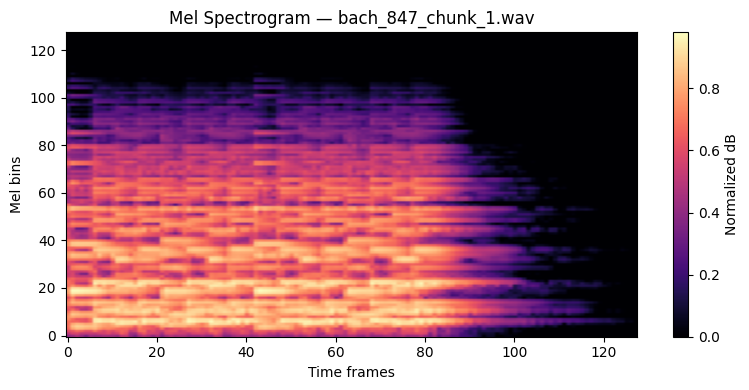

In [2]:
# ── Section 1A: Mel spectrogram helper ────────────────────────────────────────

def wav_to_melspec_tensor(wav_path: str) -> torch.Tensor:
    """
    Load a WAV file and return a (3, MEL_H, MEL_W) float32 tensor
    ready for the CNN.

    Steps:
      1. Load audio at target SR.
      2. Compute mel spectrogram (power).
      3. Convert to dB and min-max normalize to [0, 1].
      4. Resize to (MEL_H, MEL_W) via PIL bicubic.
      5. Repeat grayscale channel 3× for RGB-style input.
    """
    audio, _ = librosa.load(wav_path, sr=SR, mono=True)
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)   # shape: (n_mels, time)

    # Normalize to [0, 1]
    mel_min, mel_max = mel_db.min(), mel_db.max()
    if mel_max - mel_min > 1e-6:
        mel_norm = (mel_db - mel_min) / (mel_max - mel_min)
    else:
        mel_norm = np.zeros_like(mel_db)

    # Resize to (MEL_H, MEL_W) using PIL
    img = Image.fromarray((mel_norm * 255).astype(np.uint8), mode='L')
    img = img.resize((MEL_W, MEL_H), Image.BICUBIC)   # PIL: (width, height)
    mel_resized = np.array(img).astype(np.float32) / 255.0  # (MEL_H, MEL_W)

    # (1, H, W) → (3, H, W) by repeating the channel
    tensor = torch.from_numpy(mel_resized).unsqueeze(0).repeat(3, 1, 1)
    return tensor


# ── Section 1B: CNN model (ResNet18 without head) ─────────────────────────────

class MelCNNEmbedder(nn.Module):
    """
    Pretrained ResNet18 with the final FC layer replaced by identity.
    Outputs a 512-dim L2-normalized embedding per mel spectrogram.
    """
    def __init__(self):
        super().__init__()
        backbone = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
        # Drop the classification head; keep up to avgpool → 512-dim
        self.features = nn.Sequential(*list(backbone.children())[:-1])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, 3, H, W)
        feat = self.features(x)          # (batch, 512, 1, 1)
        feat = feat.flatten(1)           # (batch, 512)
        return F.normalize(feat, p=2, dim=1)  # L2-normalized


# ImageNet normalization for ResNet
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def normalize_imagenet(t: torch.Tensor) -> torch.Tensor:
    """Apply ImageNet mean/std normalization to a (3, H, W) tensor."""
    return (t - IMAGENET_MEAN) / IMAGENET_STD


cnn_model = MelCNNEmbedder().to(DEVICE)
cnn_model.eval()
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"MelCNNEmbedder loaded. Total params: {total_params:,}  Embed dim: {EMBED_DIM}")


# ── Section 1C: Sanity-check on a single file ──────────────────────────────────
def quick_sanity_check():
    """Find the first .wav in ChunkSamples and check the full pipeline."""
    for root, _, files in os.walk(CHUNK_PATH):
        for f in files:
            if f.endswith('.wav'):
                path = os.path.join(root, f)
                print(f"Sanity check on: {path}")
                t = wav_to_melspec_tensor(path)           # (3, H, W)
                print(f"  Mel tensor shape : {tuple(t.shape)}  range [{t.min():.3f}, {t.max():.3f}]")
                with torch.no_grad():
                    emb = cnn_model(normalize_imagenet(t).unsqueeze(0).to(DEVICE))
                print(f"  Embedding shape  : {tuple(emb.shape)}  L2-norm: {emb.norm().item():.4f}")

                # Visualize the mel spectrogram
                mel_np = t[0].numpy()  # (H, W) grayscale
                plt.figure(figsize=(8, 4))
                plt.imshow(mel_np, aspect='auto', origin='lower', cmap='magma')
                plt.colorbar(label='Normalized dB')
                plt.title(f'Mel Spectrogram — {f}')
                plt.xlabel('Time frames')
                plt.ylabel('Mel bins')
                plt.tight_layout()
                plt.show()
                return

quick_sanity_check()

## Section 2 — Build Classic Chunk Embeddings

Walks `ChunkSamples/` (structure: `composer/song/chunk_N.wav`),
computes mel spectrogram → CNN embedding for every chunk, and saves to pickle.

**Skip cell if `classic_embeddings.pkl` already exists on Drive.**

In [3]:
# ── Section 2: Classic chunk embeddings ───────────────────────────────────────

CLASSIC_EMB_PATH = os.path.join(DRIVE_BASE, "results", "classic_embeddings.pkl")

if os.path.exists(CLASSIC_EMB_PATH):
    print(f"Found existing embeddings → loading from {CLASSIC_EMB_PATH}")
    classic_df = pd.read_pickle(CLASSIC_EMB_PATH)
    print(f"Loaded {len(classic_df)} classic chunk embeddings.")
    print(classic_df.head())
else:
    # Collect all WAV paths
    classic_records = []   # [{filename, composer, song, chunk, path}]
    for composer in sorted(os.listdir(CHUNK_PATH)):
        composer_path = os.path.join(CHUNK_PATH, composer)
        if not os.path.isdir(composer_path):
            continue
        for song in sorted(os.listdir(composer_path)):
            song_path = os.path.join(composer_path, song)
            if not os.path.isdir(song_path):
                continue
            for f in sorted(os.listdir(song_path)):
                if not f.endswith('.wav'):
                    continue
                m = re.search(r'_chunk_(\d+)\.wav$', f)
                chunk_num = int(m.group(1)) if m else -1
                classic_records.append({
                    'filename': f,
                    'composer': composer,
                    'song': song,
                    'chunk': chunk_num,
                    'path': os.path.join(song_path, f),
                })

    print(f"Found {len(classic_records)} classic chunks across {len(set(r['composer'] for r in classic_records))} composers.")

    # ── Dataset & DataLoader ──────────────────────────────────────────────────
    class MelDataset(Dataset):
        def __init__(self, records):
            self.records = records

        def __len__(self):
            return len(self.records)

        def __getitem__(self, idx):
            rec = self.records[idx]
            try:
                tensor = wav_to_melspec_tensor(rec['path'])   # (3, H, W)
                tensor = normalize_imagenet(tensor)
                ok = True
            except Exception:
                tensor = torch.zeros(3, MEL_H, MEL_W)
                ok = False
            return tensor, idx, ok

    def collate_fn(batch):
        tensors, idxs, oks = zip(*batch)
        return torch.stack(tensors), list(idxs), list(oks)

    dataset = MelDataset(classic_records)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn, num_workers=2, pin_memory=True)

    # ── Extract embeddings ────────────────────────────────────────────────────
    embeddings_map = {}   # idx → embedding np array
    cnn_model.eval()

    with torch.no_grad():
        for tensors, idxs, oks in tqdm(loader, desc="Embedding classic chunks"):
            tensors = tensors.to(DEVICE)
            embs = cnn_model(tensors).cpu().numpy()  # (batch, 512)
            for i, (idx, ok) in enumerate(zip(idxs, oks)):
                if ok:
                    embeddings_map[idx] = embs[i]

    # Build DataFrame
    rows = []
    for idx, rec in enumerate(classic_records):
        if idx in embeddings_map:
            rows.append({**rec, 'embedding': embeddings_map[idx]})

    classic_df = pd.DataFrame(rows)
    classic_df.to_pickle(CLASSIC_EMB_PATH)
    print(f"\nSaved {len(classic_df)} classic embeddings → {CLASSIC_EMB_PATH}")
    print(classic_df[['filename', 'composer', 'song', 'chunk']].head())

Found 43663 classic chunks across 19 composers.


Embedding classic chunks:   0%|          | 0/1365 [00:00<?, ?it/s]/tmp/ipykernel_3352/1890556920.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((mel_norm * 255).astype(np.uint8), mode='L')
/tmp/ipykernel_3352/1890556920.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((mel_norm * 255).astype(np.uint8), mode='L')
Embedding classic chunks: 100%|██████████| 1365/1365 [1:37:37<00:00,  4.29s/it]



Saved 43663 classic embeddings → /content/drive/MyDrive/AAI-590 Capstone/checkpoints_cnn_mel/results/classic_embeddings.pkl
                filename composer      song  chunk
0   alb_esp1_chunk_1.wav  albeniz  alb_esp1      1
1  alb_esp1_chunk_10.wav  albeniz  alb_esp1     10
2  alb_esp1_chunk_11.wav  albeniz  alb_esp1     11
3  alb_esp1_chunk_12.wav  albeniz  alb_esp1     12
4  alb_esp1_chunk_13.wav  albeniz  alb_esp1     13


## Section 3 — FAISS Index Construction

Builds a **FAISS `IndexFlatIP`** (inner-product / cosine on L2-normalized vectors)
from all classic chunk embeddings.

In [4]:
# ── Section 3: FAISS index ─────────────────────────────────────────────────────
!pip install -q faiss-cpu
import faiss

# Stack embeddings (float32 contiguous required by FAISS)
classic_embs = np.vstack(classic_df['embedding'].values).astype('float32')
print(f"classic_embs shape: {classic_embs.shape}")

# IndexFlatIP = cosine similarity search (vectors already L2-normalized)
d = EMBED_DIM
faiss_index = faiss.IndexFlatIP(d)
faiss_index.add(classic_embs)
print(f"FAISS IndexFlatIP built. Vectors indexed: {faiss_index.ntotal}")

# Save index to Drive for reuse
INDEX_PATH = os.path.join(DRIVE_BASE, "results", "classic_faiss.index")
faiss.write_index(faiss_index, INDEX_PATH)
print(f"Index saved → {INDEX_PATH}")

classic_embs shape: (43663, 512)
FAISS IndexFlatIP built. Vectors indexed: 43663
Index saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints_cnn_mel/results/classic_faiss.index


## Section 4 — Build Test Chunk Embeddings

Processes all `.wav` files under `TestingSamples/TestChunks/` using the same
mel spectrogram → CNN pipeline.

In [6]:
TEST_CHUNK_DIR  = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/TestingSamples/TestChunks"

In [9]:
# ── Section 4: Test chunk embeddings ──────────────────────────────────────────

TEST_EMB_PATH = os.path.join(DRIVE_BASE, "results", "test_embeddings_new.pkl")

if os.path.exists(TEST_EMB_PATH):
    print(f"Found existing test embeddings → loading from {TEST_EMB_PATH}")
    test_df = pd.read_pickle(TEST_EMB_PATH)
    print(f"Loaded {len(test_df)} test chunk embeddings.")
    print(test_df.head())
else:
    # Collect all test WAV paths
    test_records = []
    for root, dirs, files in os.walk(TEST_CHUNK_DIR):
        for f in sorted(files):
            if not f.endswith('.wav'):
                continue
            m = re.search(r'_chunk_(\d+)\.wav$', f)
            chunk_num = int(m.group(1)) if m else -1
            test_records.append({
                'filename': f,
                'song': os.path.basename(root),
                'chunk': chunk_num,
                'path': os.path.join(root, f),
            })

    print(f"Found {len(test_records)} test chunks in {TEST_CHUNK_DIR}")

    class MelDataset(Dataset):
        def __init__(self, records):
            self.records = records

        def __len__(self):
            return len(self.records)

        def __getitem__(self, idx):
            rec = self.records[idx]
            try:
                tensor = wav_to_melspec_tensor(rec['path'])
                tensor = normalize_imagenet(tensor)
                ok = True
            except Exception:
                tensor = torch.zeros(3, MEL_H, MEL_W)
                ok = False
            return tensor, idx, ok

    def collate_fn(batch):
        tensors, idxs, oks = zip(*batch)
        return torch.stack(tensors), list(idxs), list(oks)

    test_dataset = MelDataset(test_records)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              collate_fn=collate_fn, num_workers=2, pin_memory=True)

    test_emb_map = {}
    cnn_model.eval()
    with torch.no_grad():
        for tensors, idxs, oks in tqdm(test_loader, desc="Embedding test chunks"):
            tensors = tensors.to(DEVICE)
            embs = cnn_model(tensors).cpu().numpy()
            for i, (idx, ok) in enumerate(zip(idxs, oks)):
                if ok:
                    test_emb_map[idx] = embs[i]

    rows = []
    for idx, rec in enumerate(test_records):
        if idx in test_emb_map:
            rows.append({**rec, 'embedding': test_emb_map[idx]})

    test_df = pd.DataFrame(rows)
    test_df.to_pickle(TEST_EMB_PATH)
    print(f"\nSaved {len(test_df)} test embeddings → {TEST_EMB_PATH}")
    print(test_df[['filename', 'song', 'chunk']].head())

Found 1188 test chunks in /content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/TestingSamples/TestChunks


Embedding test chunks:   0%|          | 0/38 [00:00<?, ?it/s]/tmp/ipykernel_3352/1890556920.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((mel_norm * 255).astype(np.uint8), mode='L')
/tmp/ipykernel_3352/1890556920.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((mel_norm * 255).astype(np.uint8), mode='L')
Embedding test chunks: 100%|██████████| 38/38 [03:03<00:00,  4.84s/it]


Saved 1188 test embeddings → /content/drive/MyDrive/AAI-590 Capstone/checkpoints_cnn_mel/results/test_embeddings_new.pkl
                   filename         song  chunk
0   Ballad op53_chunk_1.wav  Ballad op53      1
1  Ballad op53_chunk_10.wav  Ballad op53     10
2  Ballad op53_chunk_11.wav  Ballad op53     11
3  Ballad op53_chunk_12.wav  Ballad op53     12
4  Ballad op53_chunk_13.wav  Ballad op53     13


## Section 5 — Similarity Search

Queries the FAISS index with every test chunk and retrieves the **top-10 most similar**
classic chunks. Reports inner-product similarity (= cosine similarity for L2-normalized vectors).

In [10]:
# ── Section 5A: Run FAISS search ──────────────────────────────────────────────

K = 10  # top-K matches

test_embs = np.vstack(test_df['embedding'].values).astype('float32')
print(f"Querying FAISS with {len(test_embs)} test chunks (top-{K} matches)...")

scores, indices = faiss_index.search(test_embs, K)  # scores = cosine similarity

# Build results DataFrame
results_rows = []
for i, row in test_df.reset_index(drop=True).iterrows():
    entry = {
        'Query_File': row['filename'],
        'Query_Song': row['song'],
        'Query_Chunk': row['chunk'],
    }
    for rank in range(K):
        match_idx  = int(indices[i][rank])
        match_row  = classic_df.iloc[match_idx]
        cos_sim    = float(scores[i][rank])
        entry[f'Rank_{rank+1}_Match']    = match_row['filename']
        entry[f'Rank_{rank+1}_Song']     = match_row['song']
        entry[f'Rank_{rank+1}_Composer'] = match_row['composer']
        entry[f'Rank_{rank+1}_Sim']      = round(cos_sim, 4)
    results_rows.append(entry)

results_df = pd.DataFrame(results_rows)

RESULTS_CSV = os.path.join(DRIVE_BASE, "results", "test_search_results.csv")
results_df.to_csv(RESULTS_CSV, index=False)
print(f"Saved search results → {RESULTS_CSV}")
print(f"\nSample results (first 5 queries, top-3 matches):")

display_cols = ['Query_File', 'Query_Song',
                'Rank_1_Song', 'Rank_1_Composer', 'Rank_1_Sim',
                'Rank_2_Song', 'Rank_2_Composer', 'Rank_2_Sim',
                'Rank_3_Song', 'Rank_3_Composer', 'Rank_3_Sim']
display(results_df[display_cols].head())

Querying FAISS with 1188 test chunks (top-10 matches)...
Saved search results → /content/drive/MyDrive/AAI-590 Capstone/checkpoints_cnn_mel/results/test_search_results.csv

Sample results (first 5 queries, top-3 matches):


,Query_File,Query_Song,Rank_1_Song,Rank_1_Composer,Rank_1_Sim,Rank_2_Song,Rank_2_Composer,Rank_2_Sim,Rank_3_Song,Rank_3_Composer,Rank_3_Sim
0,Ballad op53_chunk_1.wav,Ballad op53,grieg_march,grieg,0.8658,appass_2,beeth,0.8580,burg_gewitter,burgm,0.8574
1,Ballad op53_chunk_10.wav,Ballad op53,muss_2,muss,0.9222,scn16_4,schumann,0.8788,muss_2,muss,0.8731
2,Ballad op53_chunk_11.wav,Ballad op53,muss_2,muss,0.9071,muss_2,muss,0.8840,pathetique_2,beeth,0.8800
3,Ballad op53_chunk_12.wav,Ballad op53,liz_donjuan,liszt,0.8753,muss_2,muss,0.8748,appass_3,beeth,0.8649
4,Ballad op53_chunk_13.wav,Ballad op53,chp_op31,chopin,0.8255,muss_2,muss,0.8216,chpn_op27_1,chopin,0.8179


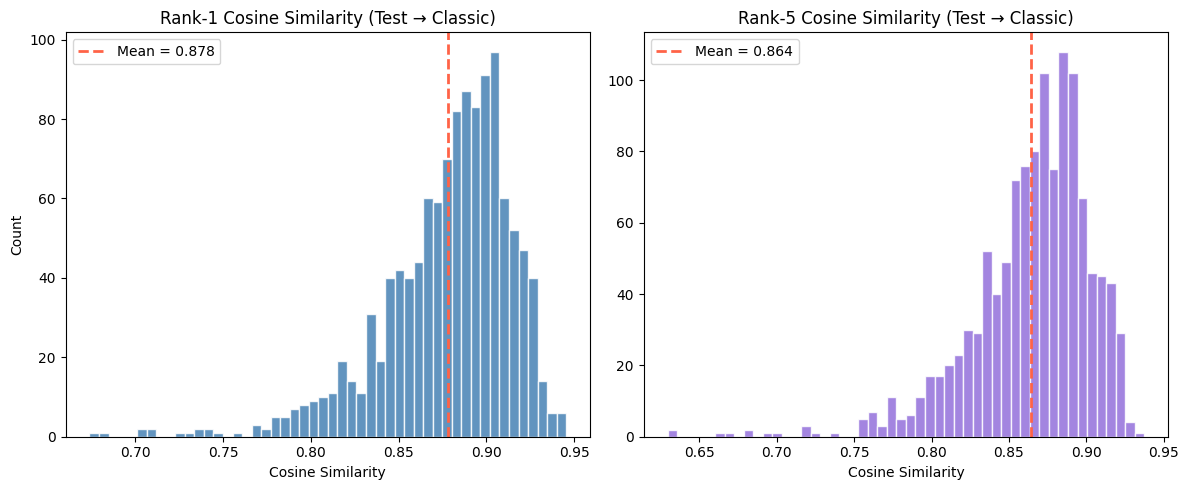


Mean Rank-1 cosine similarity per test song (top 15):
Query_Song
Prelude n06 op28 ''Tolling Bells''              0.920617
FurElise_4thVerse_K-Gmin_T-63_bothhands         0.918600
FurElise_4thVerse_K-Amin_T-79_bothhands         0.914300
Piano Sonata n08 op13 2mov ''Pathetique''       0.909568
Piano Sonata n21 2mov ''Waldstein''             0.909406
Prelude n07 op28 ''The Polish Dance''           0.906650
Prelude n09 op28 ''Vision''                     0.906460
Prelude n10 op28 ''The Night Moth''             0.906200
FurElise_Intro-2ndVers_K-Amin_T-70_bothhands    0.904750
Prelude n15 op28 ''Raindrop''                   0.904394
Prelude n04 op28 ''Suffocation''                0.903567
Prelude n13 op28 ''Loss''                       0.903040
Etude op25 n03                                  0.903033
Piano Sonata n23 op57 2mov ''Apassionata''      0.902613
Prelude n20 op28 ''Funeral March''              0.901760


In [11]:
# ── Section 5B: Visualize similarity distribution ────────────────────────────

rank1_sims = results_df['Rank_1_Sim'].values
rank5_sims = results_df['Rank_5_Sim'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(rank1_sims, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(rank1_sims.mean(), color='tomato', linestyle='--', linewidth=2,
                label=f'Mean = {rank1_sims.mean():.3f}')
axes[0].set_title('Rank-1 Cosine Similarity (Test → Classic)')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(rank5_sims, bins=50, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].axvline(rank5_sims.mean(), color='tomato', linestyle='--', linewidth=2,
                label=f'Mean = {rank5_sims.mean():.3f}')
axes[1].set_title('Rank-5 Cosine Similarity (Test → Classic)')
axes[1].set_xlabel('Cosine Similarity')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, "results", "similarity_distribution.png"), dpi=150)
plt.show()

# Per-song mean similarity (top-1)
per_song = results_df.groupby('Query_Song')['Rank_1_Sim'].mean().sort_values(ascending=False)
print("\nMean Rank-1 cosine similarity per test song (top 15):")
print(per_song.head(15).to_string())

/tmp/ipykernel_3352/1890556920.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((mel_norm * 255).astype(np.uint8), mode='L')


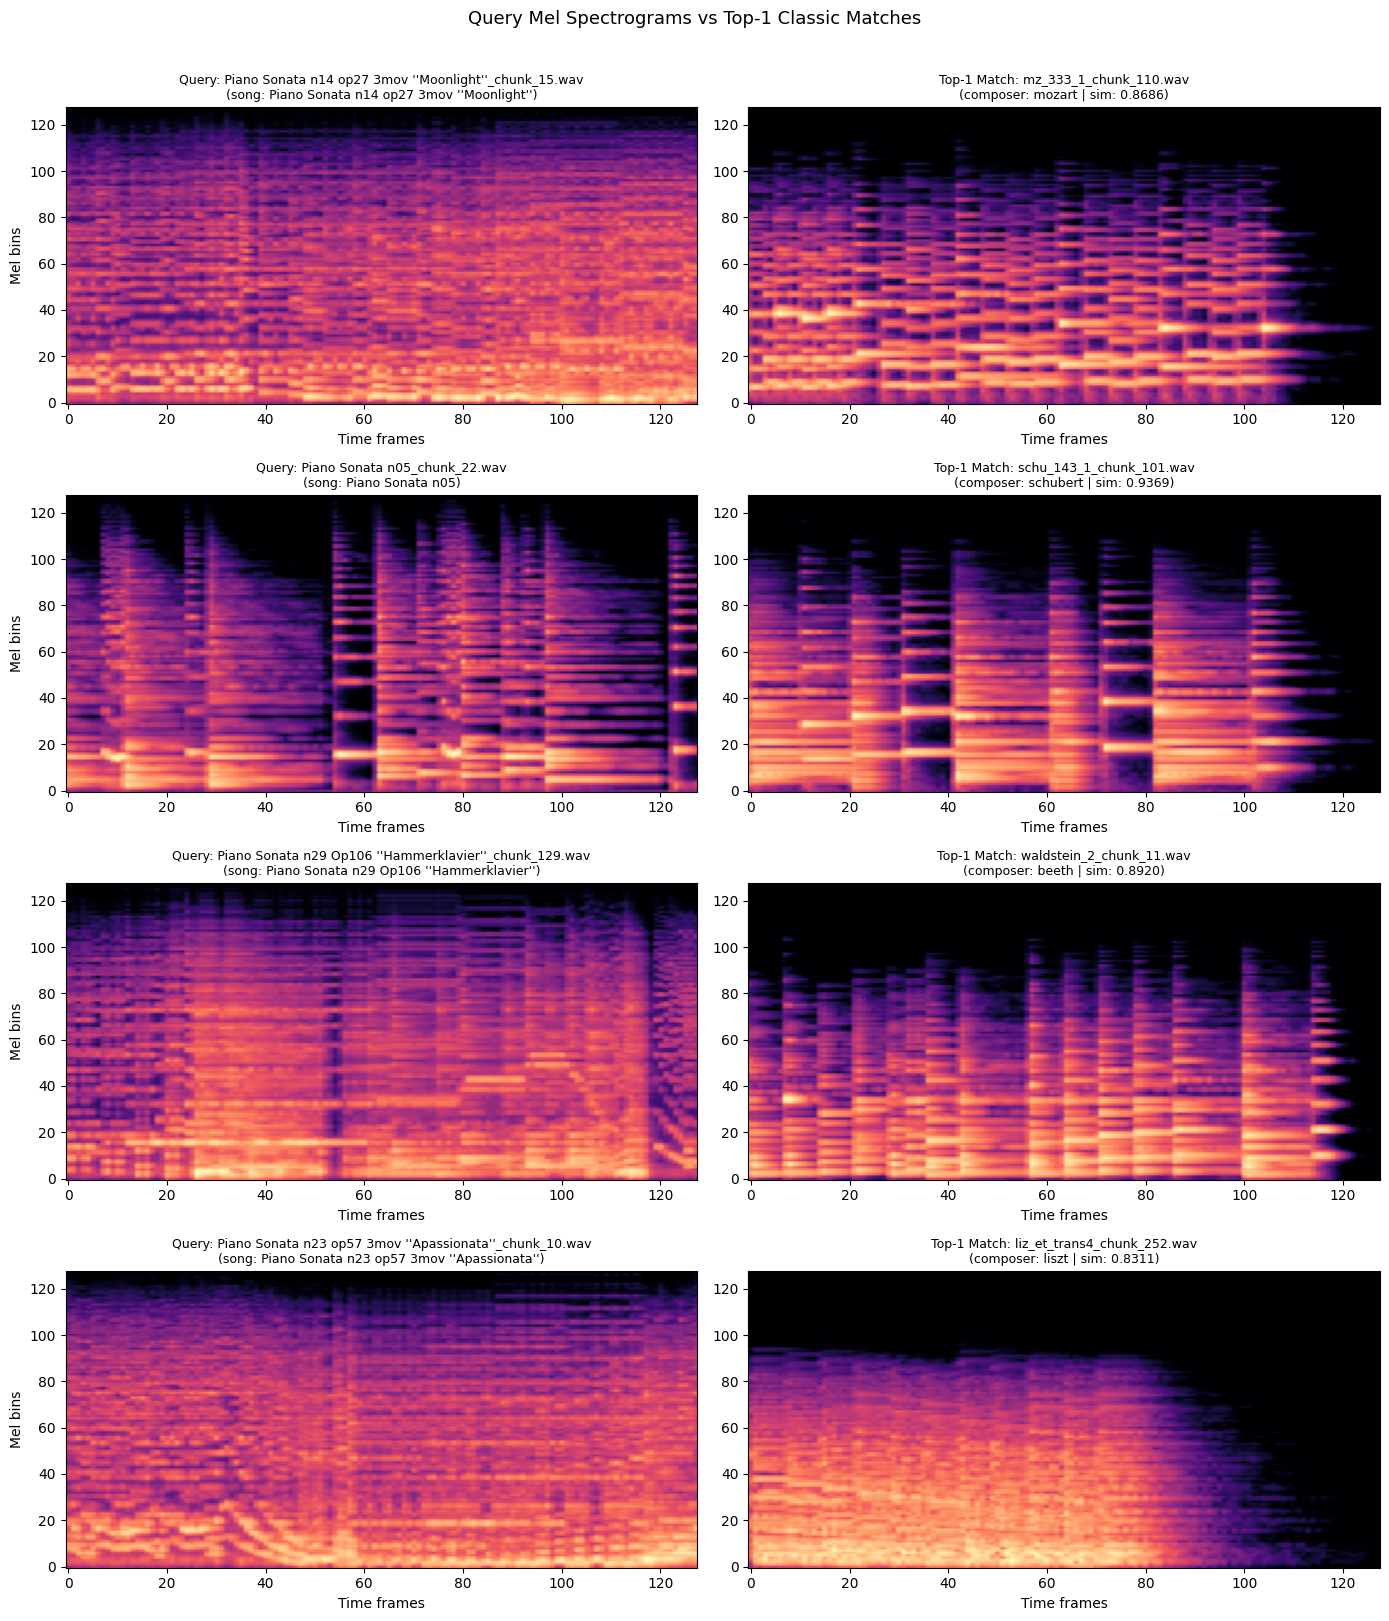

In [12]:
# ── Section 5C: Side-by-side mel spec visualization (query vs top-1 match) ───

import random
random.seed(SEED)

sample_indices = random.sample(range(len(test_df)), min(4, len(test_df)))

fig, axes = plt.subplots(len(sample_indices), 2,
                         figsize=(14, 4 * len(sample_indices)))

for row_i, qi in enumerate(sample_indices):
    query_row  = test_df.iloc[qi]
    result_row = results_df.iloc[qi]

    match_idx   = int(indices[qi][0])
    match_rec   = classic_df.iloc[match_idx]

    # Load mel specs
    q_mel  = wav_to_melspec_tensor(query_row['path'])[0].numpy()
    m_mel  = wav_to_melspec_tensor(match_rec['path'])[0].numpy()

    ax_q = axes[row_i][0]
    ax_m = axes[row_i][1]

    ax_q.imshow(q_mel, aspect='auto', origin='lower', cmap='magma')
    ax_q.set_title(f"Query: {query_row['filename']}\n(song: {query_row['song']})", fontsize=9)
    ax_q.set_xlabel('Time frames'); ax_q.set_ylabel('Mel bins')

    ax_m.imshow(m_mel, aspect='auto', origin='lower', cmap='magma')
    cos_sim = result_row['Rank_1_Sim']
    ax_m.set_title(
        f"Top-1 Match: {match_rec['filename']}\n"
        f"(composer: {match_rec['composer']} | sim: {cos_sim:.4f})",
        fontsize=9
    )
    ax_m.set_xlabel('Time frames')

plt.suptitle('Query Mel Spectrograms vs Top-1 Classic Matches', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, "results", "mel_spec_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Recall@K Evaluation

Requires `TestingReferences.csv` uploaded to `/content/TestingReferences.csv`.
Columns expected: `FileName` (test file), `OriginalFileName` (ground-truth classic song stem).

Skip this section if the reference CSV is not available.

In [13]:

REF_CSV_PATH    = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/TestingSamples/TestingReferences.csv"

Loaded reference CSV: 107 rows


,FileName,FullTestPath,OriginalFileName
0,FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.wav,audio/Beethoven/FurElise_Intro-2ndVers_K-Amin_...,elise.mid
1,FurElise_Intro_K-Amaj_T-138_bothhands_swing.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-138_bo...,elise.mid
2,FurElise_Intro_K-Amaj_T-138_righthand_swing.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-138_ri...,elise.mid
3,FurElise_Intro_K-Amaj_T-70_righthand.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-70_rig...,elise.mid
4,FurElise_Intro_K-Cmin_T-65_righthand.wav,audio/Beethoven/FurElise_Intro_K-Cmin_T-65_rig...,elise.mid



Total valid queries evaluated: 1142
Recall@01: 0.0123
Recall@03: 0.0368
Recall@05: 0.0578
Recall@10: 0.0919
Recall CSV saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints_cnn_mel/results/recall_at_k.csv


/tmp/ipykernel_3352/4039333195.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')


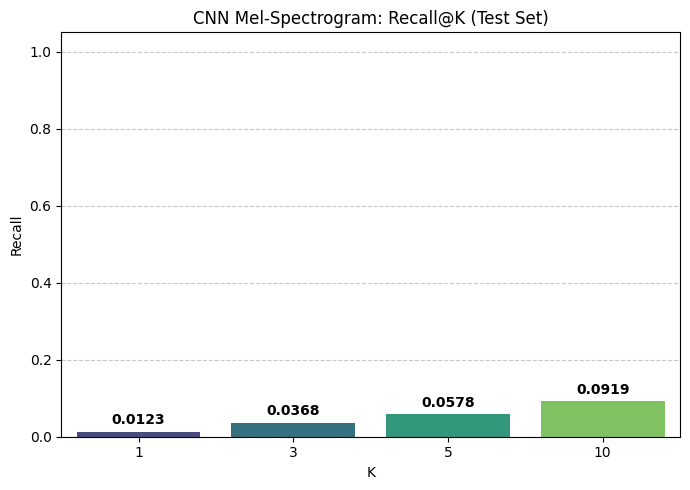

In [14]:
# ── Section 6: Recall@K evaluation ───────────────────────────────────────────

if not os.path.exists(REF_CSV_PATH):
    print(f"Reference CSV not found at {REF_CSV_PATH} — skipping Recall@K evaluation.")
else:
    ref_df = pd.read_csv(REF_CSV_PATH)
    print(f"Loaded reference CSV: {len(ref_df)} rows")
    display(ref_df.head())

    col_query = 'FileName'
    col_truth = 'OriginalFileName'

    # Build mapping: cleaned test song base → truth classic song stem
    truth_mapping = {}
    for q, t in zip(ref_df[col_query], ref_df[col_truth]):
        if pd.isna(q) or pd.isna(t):
            continue
        clean_q = str(q).rsplit('.', 1)[0]  # strip extension
        clean_t = str(t).rsplit('.', 1)[0]
        truth_mapping[clean_q] = clean_t

    recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}
    total_evaluated = 0

    for _, row in results_df.iterrows():
        query_file = row['Query_File']
        base_query = query_file.rsplit('_chunk_', 1)[0]

        if base_query not in truth_mapping:
            continue

        true_song = truth_mapping[base_query]
        total_evaluated += 1

        predicted_songs = [
            row[f'Rank_{rank}_Song'] for rank in range(1, 11)
        ]

        for k in recall_at_k:
            if true_song in predicted_songs[:k]:
                recall_at_k[k] += 1

    print(f"\nTotal valid queries evaluated: {total_evaluated}")
    recall_data = []
    for k, hits in recall_at_k.items():
        recall = hits / total_evaluated if total_evaluated > 0 else 0.0
        recall_data.append({'K': k, 'Recall': recall})
        print(f"Recall@{k:02d}: {recall:.4f}")

    recall_df = pd.DataFrame(recall_data)

    RECALL_CSV = os.path.join(DRIVE_BASE, "results", "recall_at_k.csv")
    recall_df.to_csv(RECALL_CSV, index=False)
    print(f"Recall CSV saved → {RECALL_CSV}")

    # Plot
    plt.figure(figsize=(7, 5))
    sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')
    plt.title('CNN Mel-Spectrogram: Recall@K (Test Set)')
    plt.xlabel('K')
    plt.ylabel('Recall')
    plt.ylim(0, 1.05)
    for idx, r in recall_df.iterrows():
        plt.text(idx, r.Recall + 0.02, f"{r.Recall:.4f}", ha='center', fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_BASE, "results", "recall_at_k.png"), dpi=150)
    plt.show()